# FIT5202 2026 S2 Assignment 1 : Analysing Parking & Congestion Patterns in Melbourne

## Table of Contents
* [Part 1 : Data Loading and Transformation](#part-1)  
    - [1.1 Data Preparation and Loading](#1.1)  
    - [1.2 Data Cleansing](#1.2)
    - [1.3 Partitition and Spark UI Evidence](#1.3)    
* [Part 2 : Working with DataFrames](#2-dataframes)  
    - [2.1-2.5 Query/Analysis](#2-dataframes)  
    - [2.6 Exploratory Analysis](#2.6)  
* [Part 3 : Query Optimisation](#part-3)  

Note: Feel free to add Code/Markdown cells as you need.

# Part 1 : Data Loading and Transformation (10%) <a class="anchor" name="part-1"></a>
In this section, you need to create data frames from the given datasets, perform partitioning and use various operations to answer the queries.  

## 1.1 Data Preparation and Loading <a class="anchor" name="1.1"></a>
1. Configure the Spark session to run locally using four cores;
1. Assign an appropriate application name to the Spark session;
1. Set the session timezone explicitly to 'Australia/Melbourne';
1. Define and apply an explicit StructType schema when loading each CSV and JSON dataset. 
1. Print the schema and row count for each DataFrame;
1. Display the first five rows of each DataFrame to verify successful data loading.



In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    ArrayType,
    BooleanType,
    IntegerType,
    StringType,
    StructField,
    StructType
)

student_auth_code = "kzha0139"

spark = (
    SparkSession.builder
    # 1. Configure the Spark session to run locally using four cores;
    .master("local[4]")
    # 2. Assign an appropriate application name to the Spark session;
    .appName(f"FIT5202-A1-{student_auth_code}")
    # 3. Set the session timezone explicitly to 'Australia/Melbourne';
    .config("spark.sql.session.timeZone", "Australia/Melbourne")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Spark master:", sc.master)
print("Application name:", sc.appName)
print(
    "Session timezone:",
    spark.conf.get("spark.sql.session.timeZone")
)

Spark version: 4.1.1
Spark master: local[4]
Application name: FIT5202-A1-kzha0139
Session timezone: Australia/Melbourne


In [2]:
import os
# 4.1 set the file path of csv and json file
DATA_DIR = (
    "fit5202_2026_s2_dataset_v2/"
    "fit5202_2026_s2_dataset_v2"
)

PARKING_PATH = f"{DATA_DIR}/sensordata.csv"
TRAFFIC_PATH = f"{DATA_DIR}/traffic_count.csv"
AREA_PATH = f"{DATA_DIR}/area.json"
STREET_PATH = f"{DATA_DIR}/street.json"

data_paths = {
    "Parking": PARKING_PATH,
    "Traffic": TRAFFIC_PATH,
    "Area": AREA_PATH,
    "Street": STREET_PATH
}

print("Notebook working directory:", os.getcwd())

for name, path in data_paths.items():
    print(f"{name}: exists={os.path.exists(path)}, path={path}")

Notebook working directory: /home/student
Parking: exists=True, path=fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/sensordata.csv
Traffic: exists=True, path=fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/traffic_count.csv
Area: exists=True, path=fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/area.json
Street: exists=True, path=fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/street.json


In [3]:
# 4.2 define schema for sensordata.csv
parking_schema = StructType([
    StructField("deviceid", StringType(), True),
    StructField("arrivaltime", StringType(), True),
    StructField("departuretime", StringType(), True),
    StructField("streetmarker", StringType(), True),
    StructField("signplateid", StringType(), True),
    StructField("sign", StringType(), True),
    StructField("streetid", IntegerType(), True),
    StructField("betweenstreet1id", IntegerType(), True),
    StructField("betweenstreet2id", IntegerType(), True),
    StructField("sideofstreet", IntegerType(), True),
    StructField("sidename", StringType(), True),
    StructField("bayid", IntegerType(), True),
    StructField("inviolation", BooleanType(), True),
    StructField("vehiclepresent", BooleanType(), True),
    StructField("areaid", IntegerType(), True)
])

In [4]:
# 4.3 define schema for traffic_count.csv
traffic_schema = StructType([
    StructField("d_year", IntegerType(), True),
    StructField("d_month", IntegerType(), True),
    StructField("d_day", IntegerType(), True),
    StructField("d_hour", IntegerType(), True),
    StructField("d_minute", IntegerType(), True),
    StructField("areaid", IntegerType(), True),
    StructField("traffic_count", IntegerType(), True)
])

In [5]:
# 4.4 define nested schema(areaid, areaname in area) for area.json
area_record_schema = StructType([
    StructField("areaid", IntegerType(), True),
    StructField("areaname", StringType(), True)
])

area_file_schema = StructType([
    StructField(
        "area",
        ArrayType(area_record_schema),
        True
    )
])

In [6]:
# 4.5 define nested schema(streetid, streetname in street) for street.json
street_record_schema = StructType([
    StructField("streetid", IntegerType(), True),
    StructField("streetname", StringType(), True)
])

street_file_schema = StructType([
    StructField(
        "street",
        ArrayType(street_record_schema),
        True
    )
])

In [7]:
# 4.6 apply schema to 2 csv file
parking_raw_df = (
    spark.read
    .option("header", True)
    .schema(parking_schema)
    .csv(PARKING_PATH)
)

traffic_raw_df = (
    spark.read
    .option("header", True)
    .schema(traffic_schema)
    .csv(TRAFFIC_PATH)
)

In [8]:
# 4.7 apply schma to 2 json file
area_nested_df = (
    spark.read
    .option("multiLine", True)
    .schema(area_file_schema)
    .json(AREA_PATH)
)

area_raw_df = (
    area_nested_df
    .select(F.explode("area").alias("area_record"))
    .select("area_record.*")
)

street_nested_df = (
    spark.read
    .option("multiLine", True)
    .schema(street_file_schema)
    .json(STREET_PATH)
)

street_raw_df = (
    street_nested_df
    .select(F.explode("street").alias("street_record"))
    .select("street_record.*")
)

In [9]:
dataframes = {
    "Parking DataFrame": parking_raw_df,
    "Traffic DataFrame": traffic_raw_df,
    "Area DataFrame": area_raw_df,
    "Street DataFrame": street_raw_df
}

for name, dataframe in dataframes.items():
    print(name)
    
    # 5. Print the schema for each DataFrame;
    dataframe.printSchema()
    # 6. Display the first five rows of each DataFrame to verify successful data loading.
    dataframe.show(5, truncate=False)

Parking DataFrame
root
 |-- deviceid: string (nullable = true)
 |-- arrivaltime: string (nullable = true)
 |-- departuretime: string (nullable = true)
 |-- streetmarker: string (nullable = true)
 |-- signplateid: string (nullable = true)
 |-- sign: string (nullable = true)
 |-- streetid: integer (nullable = true)
 |-- betweenstreet1id: integer (nullable = true)
 |-- betweenstreet2id: integer (nullable = true)
 |-- sideofstreet: integer (nullable = true)
 |-- sidename: string (nullable = true)
 |-- bayid: integer (nullable = true)
 |-- inviolation: boolean (nullable = true)
 |-- vehiclepresent: boolean (nullable = true)
 |-- areaid: integer (nullable = true)

+--------+----------------------+----------------------+------------+-----------+----+--------+----------------+----------------+------------+--------+-----+-----------+--------------+------+
|deviceid|arrivaltime           |departuretime         |streetmarker|signplateid|sign|streetid|betweenstreet1id|betweenstreet2id|sideofstreet

In [10]:
# 5. Print the row count for each DataFrame;
row_counts = {}

for name, dataframe in dataframes.items():
    row_count = dataframe.count()
    row_counts[name] = row_count

    print(f"{name}: {row_count:,} rows")

Parking DataFrame: 72,912,582 rows
Traffic DataFrame: 10,956,114 rows
Area DataFrame: 38 rows
Street DataFrame: 126 rows


### 1.2 Data Cleansing and Validation <a class="anchor" name="1.2"></a>
The following tasks must be completed to ensure data quality and consistency (feel free to add code block as you see fit):
1) Identify the missing-value representations within the dataset and convert them to null. Briefly state which values were treated as missing.


In [11]:
from pyspark.sql.types import StringType

# Common text values that may represent missing information
candidate_missing_tokens = [
    "na",
    "n/a",
    "null",
    "none",
    "unknown",
    "-",
    "?"
]


def profile_missing_values(dataframe, dataframe_name):
    # Get all string columns
    string_columns = [
        field.name
        for field in dataframe.schema.fields
        if isinstance(field.dataType, StringType)
    ]

    # Count existing Spark null values
    missing_count_expressions = [
        F.count(
            F.when(F.col(column_name).isNull(), 1)
        ).alias(f"{column_name}__null")
        for column_name in dataframe.columns
    ]

    # Count blank strings and text-based missing values
    for column_name in string_columns:
        normalised_value = F.lower(
            F.trim(F.col(column_name))
        )

        missing_count_expressions.extend([
            F.count(
                F.when(normalised_value == "", 1)
            ).alias(f"{column_name}__blank"),

            F.count(
                F.when(
                    normalised_value.isin(
                        candidate_missing_tokens
                    ),
                    1
                )
            ).alias(f"{column_name}__token")
        ])

    # Calculate all missing-value counts
    result = (
        dataframe
        .select(missing_count_expressions)
        .first()
        .asDict()
    )
    print(dataframe_name)


    non_zero_result_found = False

    # Display only non-zero counts
    for metric_name, metric_count in result.items():
        if metric_count and metric_count > 0:
            print(f"{metric_name}: {metric_count:,}")
            non_zero_result_found = True

    if not non_zero_result_found:
        print("No missing values found.")

In [12]:
# Profile missing values in every DataFrame
for dataframe_name, dataframe in dataframes.items():
    profile_missing_values(
        dataframe,
        dataframe_name
    )

Parking DataFrame
signplateid__null: 25,195,820
sign__null: 25,195,820
betweenstreet2id__null: 10,606,993
Traffic DataFrame
No missing values found.
Area DataFrame
areaname__blank: 1
Street DataFrame
No missing values found.


In [13]:
# Display the blank AreaName record
area_raw_df.filter(
    F.trim(F.col("areaname")) == ""
).show(truncate=False)

+------+--------+
|areaid|areaname|
+------+--------+
|7     |        |
+------+--------+



In [14]:
def convert_missing_values_to_null(dataframe):
    # Start with the original DataFrame
    cleaned_dataframe = dataframe

    # Process string columns only
    string_columns = [
        field.name
        for field in dataframe.schema.fields
        if isinstance(field.dataType, StringType)
    ]

    for column_name in string_columns:
        normalised_value = F.lower(
            F.trim(F.col(column_name))
        )

        # Match blank strings or missing-value tokens
        is_missing = (
            (normalised_value == "")
            | normalised_value.isin(
                candidate_missing_tokens
            )
        )

        # Convert matched values to Spark null
        cleaned_dataframe = (
            cleaned_dataframe
            .withColumn(
                column_name,
                F.when(
                    is_missing,
                    F.lit(None).cast(StringType())
                ).otherwise(F.col(column_name))
            )
        )

    return cleaned_dataframe

In [15]:
# Create cleaned DataFrames
parking_clean_df = convert_missing_values_to_null(
    parking_raw_df
)

traffic_clean_df = convert_missing_values_to_null(
    traffic_raw_df
)

area_clean_df = convert_missing_values_to_null(
    area_raw_df
)

street_clean_df = convert_missing_values_to_null(
    street_raw_df
)

In [16]:
# Compare values before and after cleaning
print(
    "Raw blank AreaName count:",
    area_raw_df.filter(
        F.trim(F.col("areaname")) == ""
    ).count()
)

print(
    "Clean null AreaName count:",
    area_clean_df.filter(
        F.col("areaname").isNull()
    ).count()
)

# Display the converted record
area_clean_df.filter(
    F.col("areaname").isNull()
).show(truncate=False)

Raw blank AreaName count: 1
Clean null AreaName count: 1
+------+--------+
|areaid|areaname|
+------+--------+
|7     |NULL    |
+------+--------+



The missing-value profile identified empty CSV fields and one blank string as
the missing-value representations in the supplied datasets. Empty CSV fields
in `signplateid`, `sign` and `betweenstreet2id` were already interpreted as
Spark null values during loading. One blank `areaname` value was identified
and converted to null.

No occurrences of `NA`, `N/A`, `null`, `none`, `unknown`, `-` or `?` were
found. Existing null values were retained, while empty and whitespace-only
strings were converted to Spark null values. The original DataFrames were
kept unchanged, and separate cleaned DataFrames were created for subsequent
tasks.

2) Parse the 'ArrivalTime' and 'DepartureTime' columns and convert them to timestamp format. 

In [17]:
# Define the source timestamp format
timestamp_pattern = "MM/dd/yyyy hh:mm:ss a"

parking_clean_df = (
    parking_clean_df

    # Keep the original strings for validation
    .withColumn(
        "arrival_time_raw",
        F.col("arrivaltime")
    )
    .withColumn(
        "departure_time_raw",
        F.col("departuretime")
    )

    # Parse ArrivalTime as timestamp
    .withColumn(
        "arrivaltime",
        F.try_to_timestamp(
            F.col("arrivaltime"),
            F.lit(timestamp_pattern)
        )
    )

    # Parse DepartureTime as timestamp
    .withColumn(
        "departuretime",
        F.try_to_timestamp(
            F.col("departuretime"),
            F.lit(timestamp_pattern)
        )
    )
)

In [18]:
# Compare raw strings with parsed timestamps
parking_clean_df.select(
    "arrival_time_raw",
    "arrivaltime",
    "departure_time_raw",
    "departuretime"
).show(5, truncate=False)

+----------------------+-------------------+----------------------+-------------------+
|arrival_time_raw      |arrivaltime        |departure_time_raw    |departuretime      |
+----------------------+-------------------+----------------------+-------------------+
|10/23/2018 06:49:29 AM|2018-10-23 06:49:29|10/23/2018 06:54:24 AM|2018-10-23 06:54:24|
|02/07/2018 07:30:00 PM|2018-02-07 19:30:00|02/07/2018 07:56:23 PM|2018-02-07 19:56:23|
|11/22/2018 07:22:38 AM|2018-11-22 07:22:38|11/22/2018 07:28:22 AM|2018-11-22 07:28:22|
|09/18/2018 09:24:56 PM|2018-09-18 21:24:56|09/18/2018 09:27:44 PM|2018-09-18 21:27:44|
|01/04/2018 12:00:00 AM|2018-01-04 00:00:00|01/04/2018 03:45:46 AM|2018-01-04 03:45:46|
+----------------------+-------------------+----------------------+-------------------+
only showing top 5 rows


In [19]:
# Confirm the converted column types
parking_clean_df.select(
    "arrival_time_raw",
    "arrivaltime",
    "departure_time_raw",
    "departuretime"
).printSchema()

root
 |-- arrival_time_raw: string (nullable = true)
 |-- arrivaltime: timestamp (nullable = true)
 |-- departure_time_raw: string (nullable = true)
 |-- departuretime: timestamp (nullable = true)



The `ArrivalTime` and `DepartureTime` columns were parsed using the
`MM/dd/yyyy hh:mm:ss a` format and converted from strings to Spark timestamp
values. The original string values were retained in separate columns to
support the identification of parsing failures during validation.

3) Convert the “DeviceId” to an appropriate numeric type. 

In [20]:
# Check the numeric range of DeviceId
parking_clean_df.agg(
    F.min("deviceid").alias("MinDeviceId"),
    F.max("deviceid").alias("MaxDeviceId")
).show()

+-----------+-----------+
|MinDeviceId|MaxDeviceId|
+-----------+-----------+
|      10036|      28532|
+-----------+-----------+



In [21]:
parking_clean_df = (
    parking_clean_df

    # Keep the original value for validation
    .withColumn(
        "device_id_raw",
        F.col("deviceid")
    )

    # Convert DeviceId to IntegerType safely
    .withColumn(
        "deviceid",
        F.col("deviceid").try_cast("int")
    )
)

In [22]:
# Compare the original and converted values
parking_clean_df.select(
    "device_id_raw",
    "deviceid"
).show(5, truncate=False)

+-------------+--------+
|device_id_raw|deviceid|
+-------------+--------+
|17193        |17193   |
|17193        |17193   |
|17195        |17195   |
|17195        |17195   |
|17195        |17195   |
+-------------+--------+
only showing top 5 rows


In [23]:
# Compare the original and converted data type
parking_clean_df.select(
    "device_id_raw",
    "deviceid"
).printSchema()

root
 |-- device_id_raw: string (nullable = true)
 |-- deviceid: integer (nullable = true)



The `DeviceId` column was converted from string to numeric typr Integer. The original string value was retained in `device_id_raw` so that non-null source values that failed numeric conversion could be identified during validation.

4) Calculate a new “DurationMinutes” column using the arrival and departure timestamp. Store the result as a DoubleType value and rounded to two decimal places.

In [24]:
parking_clean_df = parking_clean_df.withColumn(
    "DurationMinutes",

    # Calculate the duration in minutes
    F.round(
        (
            F.col("departuretime").cast("long")
            - F.col("arrivaltime").cast("long")
        ) / 60.0,
        2
    ).cast("double")
)

In [25]:
# Display calculated parking durations
parking_clean_df.select(
    "arrivaltime",
    "departuretime",
    "DurationMinutes"
).show(10, truncate=False)

+-------------------+-------------------+---------------+
|arrivaltime        |departuretime      |DurationMinutes|
+-------------------+-------------------+---------------+
|2018-10-23 06:49:29|2018-10-23 06:54:24|4.92           |
|2018-02-07 19:30:00|2018-02-07 19:56:23|26.38          |
|2018-11-22 07:22:38|2018-11-22 07:28:22|5.73           |
|2018-09-18 21:24:56|2018-09-18 21:27:44|2.8            |
|2018-01-04 00:00:00|2018-01-04 03:45:46|225.77         |
|2018-07-13 00:00:00|2018-07-13 06:06:43|366.72         |
|2018-01-29 19:07:39|2018-01-29 19:11:53|4.23           |
|2018-10-20 06:29:15|2018-10-20 07:15:02|45.78          |
|2018-08-06 18:42:28|2018-08-06 18:49:11|6.72           |
|2018-01-03 07:02:17|2018-01-03 07:05:08|2.85           |
+-------------------+-------------------+---------------+
only showing top 10 rows


In [26]:
parking_clean_df.select(
    "DurationMinutes"
).printSchema()

root
 |-- DurationMinutes: double (nullable = true)



`DurationMinutes` was calculated by converting the arrival and departure
timestamps to Unix seconds, subtracting the arrival value from the departure
value, and dividing the result by 60. The result was rounded to two decimal
places and stored as DoubleType.

Records with missing or unparseable timestamps produce a null duration.
Negative duration values were retained at this stage for investigation in the
next validation task.

5) Identify and report records where the departure time is earlier than the arrival time. Briefly discuss any pattern observed and state how these records will be handled in duration-based queries.

In [35]:
from pyspark import StorageLevel

# Keep records where departure is earlier than arrival, negative parking durations
negative_duration_df = (
    parking_clean_df
    .filter(
        F.col("DurationMinutes") < 0
    )
    .cache()
)

In [36]:
# Summarise negative duration records
negative_duration_summary_df = negative_duration_df.agg(
    F.count("*").alias(
        "NegativeDurationRecords"
    ),

    F.round(
        F.min("DurationMinutes"),
        2
    ).alias(
        "MostNegativeDurationMinutes"
    ),

    F.round(
        F.max("DurationMinutes"),
        2
    ).alias(
        "ClosestToZeroDurationMinutes"
    ),

    F.round(
        F.avg("DurationMinutes"),
        2
    ).alias(
        "AverageNegativeDurationMinutes"
    )
)

negative_duration_summary_df.show(
    truncate=False
)

+-----------------------+---------------------------+----------------------------+------------------------------+
|NegativeDurationRecords|MostNegativeDurationMinutes|ClosestToZeroDurationMinutes|AverageNegativeDurationMinutes|
+-----------------------+---------------------------+----------------------------+------------------------------+
|408                    |-493288.88                 |-0.12                       |-74094.87                     |
+-----------------------+---------------------------+----------------------------+------------------------------+



A total of 408 records had negative durations, representing approximately 0.00056% of all parking records. The durations ranged from -493,288.88 to -0.12 minutes, indicating both minor timing inconsistencies and severe date-matching errors.

In [39]:
# Display the most severe negative durations
negative_duration_df.select(
    "deviceid",
    "bayid",
    "areaid",
    "arrival_time_raw",
    "departure_time_raw",
    "arrivaltime",
    "departuretime",
    "DurationMinutes"
).orderBy(
    F.asc("DurationMinutes")
).show(20, truncate=False)

+--------+-----+------+----------------------+----------------------+-------------------+-------------------+---------------+
|deviceid|bayid|areaid|arrival_time_raw      |departure_time_raw    |arrivaltime        |departuretime      |DurationMinutes|
+--------+-----+------+----------------------+----------------------+-------------------+-------------------+---------------+
|17595   |6519 |35    |12/26/2019 07:30:00 AM|01/17/2019 06:01:07 PM|2019-12-26 07:30:00|2019-01-17 18:01:07|-493288.88     |
|17595   |6519 |35    |12/22/2019 06:30:00 PM|01/18/2019 07:05:43 AM|2019-12-22 18:30:00|2019-01-18 07:05:43|-487404.28     |
|17595   |6519 |35    |12/22/2019 07:30:00 AM|01/18/2019 07:00:49 AM|2019-12-22 07:30:00|2019-01-18 07:00:49|-486749.18     |
|17595   |6519 |35    |12/24/2019 07:30:00 AM|01/20/2019 02:53:14 PM|2019-12-24 07:30:00|2019-01-20 14:53:14|-486276.77     |
|17595   |6519 |35    |12/20/2019 07:30:00 AM|01/19/2019 05:55:34 AM|2019-12-20 07:30:00|2019-01-19 05:55:34|-482494.4

The most severe records had departure timestamps several months earlier than their arrival timestamps. DeviceId 17595 and BayId 6519 appeared repeatedly, suggesting a possible sensor-event matching problem.

In [40]:
# Count records by negative-duration magnitude
negative_duration_pattern_df = negative_duration_df.agg(
    F.sum(
        F.when(
            F.col("DurationMinutes") >= -60,
            1
        ).otherwise(0)
    ).alias(
        "LessThanOneHourEarlier"
    ),

    F.sum(
        F.when(
            (F.col("DurationMinutes") < -60)
            & (F.col("DurationMinutes") >= -1440),
            1
        ).otherwise(0)
    ).alias(
        "OneHourToOneDayEarlier"
    ),

    F.sum(
        F.when(
            F.col("DurationMinutes") < -1440,
            1
        ).otherwise(0)
    ).alias(
        "MoreThanOneDayEarlier"
    )
)

negative_duration_pattern_df.show(
    truncate=False
)

+----------------------+----------------------+---------------------+
|LessThanOneHourEarlier|OneHourToOneDayEarlier|MoreThanOneDayEarlier|
+----------------------+----------------------+---------------------+
|112                   |148                   |148                  |
+----------------------+----------------------+---------------------+



Of the 408 invalid records, 112 less than one hour earlier, 148 between one hour and one day earlier, and 148 were more than one day earlier. Therefore, the anomalies were not limited to minor timing differences.

In [32]:
# Count records by negative-duration magnitude
negative_duration_pattern_df = negative_duration_df.agg(
    F.sum(
        F.when(
            F.col("DurationMinutes") >= -60,
            1
        ).otherwise(0)
    ).alias(
        "LessThanOneHourEarlier"
    ),

    F.sum(
        F.when(
            (F.col("DurationMinutes") < -60)
            & (F.col("DurationMinutes") >= -1440),
            1
        ).otherwise(0)
    ).alias(
        "OneHourToOneDayEarlier"
    ),

    F.sum(
        F.when(
            F.col("DurationMinutes") < -1440,
            1
        ).otherwise(0)
    ).alias(
        "MoreThanOneDayEarlier"
    )
)

negative_duration_pattern_df.show(
    truncate=False
)

+-------------+-----+
|DayDifference|count|
+-------------+-----+
|0            |255  |
|-86          |29   |
|-189         |11   |
|-239         |7    |
|-139         |7    |
|-45          |6    |
|-1           |5    |
|-50          |5    |
|-190         |5    |
|-44          |4    |
|-41          |4    |
|-144         |4    |
|-87          |3    |
|-338         |3    |
|-143         |3    |
|-93          |3    |
|-38          |2    |
|-141         |2    |
|-91          |2    |
|-179         |2    |
+-------------+-----+
only showing top 20 rows


255 records occurred on the same calendar date,153 crossed one or more dates. For the large negative day differences may suggest that some arrival and departure events were incorrectly matched.

In [42]:
# Check whether invalid records cluster on specific dates
negative_duration_df.groupBy(
    F.to_date(
        F.col("arrivaltime")
    ).alias("ArrivalDate")
).count().orderBy(
    F.desc("count"),
    F.asc("ArrivalDate")
).show(20, truncate=False)

+-----------+-----+
|ArrivalDate|count|
+-----------+-----+
|2019-10-06 |51   |
|2018-03-19 |37   |
|2018-10-07 |26   |
|2018-12-04 |21   |
|2019-05-08 |13   |
|2018-07-06 |12   |
|2019-04-14 |8    |
|2019-07-26 |8    |
|2018-04-21 |7    |
|2019-06-08 |7    |
|2019-07-28 |7    |
|2018-06-29 |6    |
|2019-03-04 |6    |
|2018-06-26 |5    |
|2018-06-27 |5    |
|2018-07-03 |5    |
|2019-09-16 |5    |
|2019-05-02 |4    |
|2019-06-11 |4    |
|2019-10-19 |4    |
+-----------+-----+
only showing top 20 rows


Negative durations were concentrated on several dates, particularly 2019-10-06 and 2018-10-07, when Melbourne transitioned to daylight-saving time. This suggests that some invalid durations may be related to the clock change.

In [44]:
# Check whether anomalies cluster by device and bay
negative_duration_df.groupBy(
    "deviceid",
    "bayid",
    "areaid"
).agg(
    F.count("*").alias(
        "NegativeDurationCount"
    ),

    F.round(
        F.min("DurationMinutes"),
        2
    ).alias(
        "MostNegativeDurationMinutes"
    ),

    F.round(
        F.max("DurationMinutes"),
        2
    ).alias(
        "ClosestToZeroDurationMinutes"
    )
).orderBy(
    F.desc("NegativeDurationCount")
).show(10, truncate=False)

+--------+-----+------+---------------------+---------------------------+----------------------------+
|deviceid|bayid|areaid|NegativeDurationCount|MostNegativeDurationMinutes|ClosestToZeroDurationMinutes|
+--------+-----+------+---------------------+---------------------------+----------------------------+
|17595   |6519 |35    |95                   |-493288.88                 |-44207.15                   |
|18199   |882  |11    |22                   |-124890.0                  |-53463.75                   |
|19904   |3205 |16    |6                    |-416090.1                  |-58630.55                   |
|20233   |3978 |16    |4                    |-329441.58                 |-257741.65                  |
|18689   |1708 |14    |3                    |-427022.7                  |-211740.0                   |
|19044   |2555 |25    |3                    |-561.23                    |-33.05                      |
|18468   |632  |33    |3                    |-421258.32                 |

DeviceId 17595 and BayId 6519 accounted for 95 negative-duration records, or approximately 23.28% of all invalid durations. The concentration among a small number of devices suggests systematic sensor or event-matching issues.

In [45]:
# Release the cached anomaly DataFrame
negative_duration_df.unpersist()

DataFrame[deviceid: int, arrivaltime: timestamp, departuretime: timestamp, streetmarker: string, signplateid: string, sign: string, streetid: int, betweenstreet1id: int, betweenstreet2id: int, sideofstreet: int, sidename: string, bayid: int, inviolation: boolean, vehiclepresent: boolean, areaid: int, arrival_time_raw: string, departure_time_raw: string, device_id_raw: string, DurationMinutes: double, DepartureBeforeArrival: boolean]

6) Explain how records with missing or invalid departure information will be handled in subsequent duration-based queries.

In [47]:
# Keep records with valid durations
valid_duration_df = parking_clean_df.filter(
    F.col("DurationMinutes").isNotNull()
    & (F.col("DurationMinutes") >= 0)
)

Records with missing or unparseable departure information produce a null DurationMinutes value, while records where DepartureTime is earlier than ArrivalTime produce a negative value. These records will be retained because their arrival, location and violation information may still be valid. Null and negative durations will only be excluded from metrics that require a valid parking duration, but the records may still be included in analyses that do not use duration.

7) Display and print the schema for DeviceId, ArrivalTime, DepartureTime and DurationMinutes.

In [46]:
# Select cleaned columns for validation
parking_validation_df = parking_clean_df.select(
    F.col("deviceid").alias("DeviceId"),
    F.col("arrivaltime").alias("ArrivalTime"),
    F.col("departuretime").alias("DepartureTime"),
    F.col("DurationMinutes")
)

parking_validation_df.show(5, truncate=False)
parking_validation_df.printSchema()

+--------+-------------------+-------------------+---------------+
|DeviceId|ArrivalTime        |DepartureTime      |DurationMinutes|
+--------+-------------------+-------------------+---------------+
|17193   |2018-10-23 06:49:29|2018-10-23 06:54:24|4.92           |
|17193   |2018-02-07 19:30:00|2018-02-07 19:56:23|26.38          |
|17195   |2018-11-22 07:22:38|2018-11-22 07:28:22|5.73           |
|17195   |2018-09-18 21:24:56|2018-09-18 21:27:44|2.8            |
|17195   |2018-01-04 00:00:00|2018-01-04 03:45:46|225.77         |
+--------+-------------------+-------------------+---------------+
only showing top 5 rows
root
 |-- DeviceId: integer (nullable = true)
 |-- ArrivalTime: timestamp (nullable = true)
 |-- DepartureTime: timestamp (nullable = true)
 |-- DurationMinutes: double (nullable = true)



8) Display a validation summary table containing the count for each of the following:
- total parking records;
- ArrivalTime parsing failures;
- DepartureTime parsing failures;
- DeviceId conversion failures;
- records with missing DepartureTime;
- records where DepartureTime is earlier than ArrivalTime.


In [48]:
# Create the validation summary
validation_summary_df = parking_clean_df.agg(
    
    # Count total parking records
    F.count("*").alias("TotalParkingRecords"),

    # Count ArrivalTime parsing failures
    F.sum(
        F.when(
            F.col("arrival_time_raw").isNotNull()
            & F.col("arrivaltime").isNull(),
            1
        ).otherwise(0)
    ).alias("ArrivalTimeParsingFailures"),

    # Count DepartureTime parsing failures
    F.sum(
        F.when(
            F.col("departure_time_raw").isNotNull()
            & F.col("departuretime").isNull(),
            1
        ).otherwise(0)
    ).alias("DepartureTimeParsingFailures"),

    # Count DeviceId conversion failures
    F.sum(
        F.when(
            F.col("device_id_raw").isNotNull()
            & F.col("deviceid").isNull(),
            1
        ).otherwise(0)
    ).alias("DeviceIdConversionFailures"),

    # Count records with missing DepartureTime
    F.sum(
        F.when(
            F.col("departure_time_raw").isNull(),
            1
        ).otherwise(0)
    ).alias("MissingDepartureTime"),

    # Count records where DepartureTime is earlier than ArrivalTime
    F.sum(
        F.when(
            F.col("DurationMinutes") < 0,
            1
        ).otherwise(0)
    ).alias("DepartureEarlierThanArrival")
)

# Display the validation summary
validation_summary_df.show(truncate=False)

+-------------------+--------------------------+----------------------------+--------------------------+--------------------+---------------------------+
|TotalParkingRecords|ArrivalTimeParsingFailures|DepartureTimeParsingFailures|DeviceIdConversionFailures|MissingDepartureTime|DepartureEarlierThanArrival|
+-------------------+--------------------------+----------------------------+--------------------------+--------------------+---------------------------+
|72912582           |0                         |0                           |0                         |0                   |408                        |
+-------------------+--------------------------+----------------------------+--------------------------+--------------------+---------------------------+



### 1.3 Partition and Spark UI Evidence <a class="anchor" name="1.3"></a>
1.3.1) Display the total number of partitions within the cleaned parking DataFrame.

In [41]:
parking_partition_count = (
    parking_clean_df
    .rdd
    .getNumPartitions()
)

print(
    "Total number of partitions in "
    f"parking_clean_df: {parking_partition_count}"
)

Total number of partitions in parking_clean_df: 69


1.3.2) Print the number of records in each partition. Immediately before running this action, set the following Spark Job description: sc.setJobDescription(f"A1-P1-{student_auth_code}")

In [42]:
partition_count_rdd = (
    parking_clean_df
    .select("deviceid")
    .rdd
    .mapPartitionsWithIndex(
        lambda partition_id, rows: [
            (
                partition_id,
                sum(1 for _ in rows)
            )
        ]
    )
)

In [43]:
sc.setJobDescription(
    f"A1-P1-{student_auth_code}"
)

partition_record_counts = (
    partition_count_rdd.collect()
)

sc.setJobDescription(None)

In [44]:
partition_record_counts = sorted(
    partition_record_counts,
    key=lambda item: item[0]
)

for partition_id, record_count in partition_record_counts:
    print(
        f"Partition {partition_id}: "
        f"{record_count:,} records"
    )

Partition 0: 1,093,088 records
Partition 1: 1,045,808 records
Partition 2: 1,043,416 records
Partition 3: 1,054,580 records
Partition 4: 1,095,648 records
Partition 5: 1,064,542 records
Partition 6: 1,073,063 records
Partition 7: 1,085,498 records
Partition 8: 1,069,231 records
Partition 9: 1,043,017 records
Partition 10: 1,049,272 records
Partition 11: 1,059,697 records
Partition 12: 1,051,963 records
Partition 13: 1,052,721 records
Partition 14: 1,047,821 records
Partition 15: 1,069,659 records
Partition 16: 1,051,222 records
Partition 17: 1,069,043 records
Partition 18: 1,072,379 records
Partition 19: 1,042,332 records
Partition 20: 1,053,826 records
Partition 21: 1,072,522 records
Partition 22: 1,053,381 records
Partition 23: 1,059,832 records
Partition 24: 1,058,740 records
Partition 25: 1,061,174 records
Partition 26: 1,056,094 records
Partition 27: 1,060,892 records
Partition 28: 1,059,880 records
Partition 29: 1,069,792 records
Partition 30: 1,068,101 records
Partition 31: 1,06

In [45]:
import statistics

record_counts = [
    record_count
    for _, record_count in partition_record_counts
]

total_partition_records = sum(record_counts)
average_partition_records = (
    total_partition_records / len(record_counts)
)
minimum_partition_records = min(record_counts)
maximum_partition_records = max(record_counts)
partition_standard_deviation = statistics.pstdev(
    record_counts
)
partition_cv_percentage = (
    partition_standard_deviation
    / average_partition_records
    * 100
)

print(
    "Number of partitions:",
    len(record_counts)
)
print(
    "Total records across partitions:",
    f"{total_partition_records:,}"
)
print(
    "Average records per partition:",
    f"{average_partition_records:,.2f}"
)
print(
    "Minimum records in a partition:",
    f"{minimum_partition_records:,}"
)
print(
    "Maximum records in a partition:",
    f"{maximum_partition_records:,}"
)
print(
    "Partition record-count standard deviation:",
    f"{partition_standard_deviation:,.2f}"
)
print(
    "Coefficient of variation:",
    f"{partition_cv_percentage:.2f}%"
)

Number of partitions: 69
Total records across partitions: 72,912,582
Average records per partition: 1,056,704.09
Minimum records in a partition: 580,174
Maximum records in a partition: 1,105,466
Partition record-count standard deviation: 59,500.14
Coefficient of variation: 5.63%


1.3.3) Include a set of screenshots from the Spark UI tab that clearly show:  
- the job tab with the specified job description;
- the relevant stage and its number of tasks
- the task input size, input records or task-duration distribution.

<img src="screenshots/part1/p1_jobs.png" width="100%">
Figure 1: Spark Job with the required description

Figure 1 shows Job 41 with the required job description
`A1-P1-kzha0139`. The job completed one stage and all 69 tasks successfully.


<img src="screenshots/part1/p1_stages.png" width="100%">
Figure 2: Relevant Spark stage

Figure 2 shows Stage 55, which processed 8.6 GiB of input using 69 tasks.
No shuffle read or shuffle write was required.


<img src="screenshots/part1/p1_stage55_details.png" width="100%">
Figure 3: Task input and duration distribution

Figure 3 shows the Stage 55 task timeline and summary metrics. The stage
processed 72,912,582 records, and most tasks received approximately
128.1 MiB of input and completed in approximately 5 seconds.

1.3.4) Analyse the figures in the screenshot and briefly comment on whether the workload appears evenly distributed across the partitions. If not, why?

The partition workload appears broadly balanced. Stage 55 processed
72,912,582 records (8.6 GiB) across 69 tasks. The 25th percentile, median and
75th percentile input sizes were all approximately 128.1 MiB, while their
record counts were 1,054,410, 1,060,997 and 1,070,071 respectively. This
shows that most tasks received a similar amount of data.

Task durations were also consistent: the median and both middle quartiles
were approximately 5 seconds, with an overall range of 3–6 seconds. There
was no long-running task suggesting significant data skew.

The minimum partition contained 69.1 MiB and 580,174 records. This was likely
the final residual file split, which was smaller because the input file size
was not an exact multiple of the target partition size. Therefore, the
workload was sufficiently balanced despite one naturally smaller final
partition.

1.3.5) Provide a concise explanation detailing how Spark determines the initial number and approximate size of input partitions when reading from a CSV file.

Spark determines the initial CSV input partitions primarily from the input
file size and the configured maximum number of bytes per file partition.
For file-based data sources, the relevant setting is
`spark.sql.files.maxPartitionBytes`, whose default value is approximately
128 MiB. Spark may also consider the file open cost, filesystem block
information and the configured minimum or maximum partition numbers.

Because CSV is a splittable, line-oriented format, Spark divided the 8.6 GiB
parking file into approximately 128 MiB input splits while preserving record
boundaries. This produced 69 input partitions. Most partitions were about
128.1 MiB, while the final partition was only 69.1 MiB because it contained
the remaining bytes at the end of the file.

The `local[4]` setting does not determine the number of input partitions. It
controls how many tasks can execute concurrently. The narrow cleansing
transformations did not require a shuffle or change the original input
partition count, so the cleaned parking DataFrame retained the 69 CSV input
partitions.

## Part 2. Working with DataFrames (35%) <a class="anchor" name="2-dataframes"></a>
In this section, you need to use DataFrame functions to answer the queries.

2.1 Create the time attributes  
2.1.1) From ArrivalTime, create columns for: year; month; day of week;  arrival hour and arrival minute;.

In [46]:
parking_time_df = (
    parking_clean_df
    .withColumn(
        "Year",
        F.year(F.col("arrivaltime"))
    )
    .withColumn(
        "Month",
        F.month(F.col("arrivaltime"))
    )
    .withColumn(
        "DayOfWeek",
        F.dayofweek(F.col("arrivaltime"))
    )
    .withColumn(
        "ArrivalHour",
        F.hour(F.col("arrivaltime"))
    )
    .withColumn(
        "ArrivalMinute",
        F.minute(F.col("arrivaltime"))
    )
)

In [47]:
parking_time_df.select(
    F.col("arrivaltime").alias("ArrivalTime"),
    "Year",
    "Month",
    "DayOfWeek",
    "ArrivalHour",
    "ArrivalMinute"
).show(10, truncate=False)

+-------------------+----+-----+---------+-----------+-------------+
|ArrivalTime        |Year|Month|DayOfWeek|ArrivalHour|ArrivalMinute|
+-------------------+----+-----+---------+-----------+-------------+
|2018-10-23 06:49:29|2018|10   |3        |6          |49           |
|2018-02-07 19:30:00|2018|2    |4        |19         |30           |
|2018-11-22 07:22:38|2018|11   |5        |7          |22           |
|2018-09-18 21:24:56|2018|9    |3        |21         |24           |
|2018-01-04 00:00:00|2018|1    |5        |0          |0            |
|2018-07-13 00:00:00|2018|7    |6        |0          |0            |
|2018-01-29 19:07:39|2018|1    |2        |19         |7            |
|2018-10-20 06:29:15|2018|10   |7        |6          |29           |
|2018-08-06 18:42:28|2018|8    |2        |18         |42           |
|2018-01-03 07:02:17|2018|1    |4        |7          |2            |
+-------------------+----+-----+---------+-----------+-------------+
only showing top 10 rows


2.1.2) With day of week and hour and minutes, create a new column named isPeak and set the value to True or False (i.e. True = Peak Hour, False = Non-peak hour).  
- Peak hours are:
- Weekdays 7:00 - 9:00 am (excluding 9:00 am) and 4:00 - 6:30 pm ( excluding 6:30 pm).
- Non-peak hours are times outside these periods.
- Represent day of week using Spark’s convention: 1 = Sunday, 2 = Monday……

In [48]:
arrival_minutes_of_day = (
    F.col("ArrivalHour") * 60
    + F.col("ArrivalMinute")
)

is_weekday = F.col("DayOfWeek").between(2, 6)

is_morning_peak = (
    (arrival_minutes_of_day >= 7 * 60)
    & (arrival_minutes_of_day < 9 * 60)
)

is_evening_peak = (
    (arrival_minutes_of_day >= 16 * 60)
    & (arrival_minutes_of_day < 18 * 60 + 30)
)

parking_time_df = parking_time_df.withColumn(
    "isPeak",
    F.coalesce(
        is_weekday
        & (
            is_morning_peak
            | is_evening_peak
        ),
        F.lit(False)
    )
)

In [49]:
parking_time_df.select(
    F.col("arrivaltime").alias("ArrivalTime"),
    "DayOfWeek",
    "ArrivalHour",
    "ArrivalMinute",
    "isPeak"
).show(10, truncate=False)

+-------------------+---------+-----------+-------------+------+
|ArrivalTime        |DayOfWeek|ArrivalHour|ArrivalMinute|isPeak|
+-------------------+---------+-----------+-------------+------+
|2018-10-23 06:49:29|3        |6          |49           |false |
|2018-02-07 19:30:00|4        |19         |30           |false |
|2018-11-22 07:22:38|5        |7          |22           |true  |
|2018-09-18 21:24:56|3        |21         |24           |false |
|2018-01-04 00:00:00|5        |0          |0            |false |
|2018-07-13 00:00:00|6        |0          |0            |false |
|2018-01-29 19:07:39|2        |19         |7            |false |
|2018-10-20 06:29:15|7        |6          |29           |false |
|2018-08-06 18:42:28|2        |18         |42           |false |
|2018-01-03 07:02:17|4        |7          |2            |true  |
+-------------------+---------+-----------+-------------+------+
only showing top 10 rows


2.1.3) Display five rows containing ArrivalTime, year, month, day of week, arrival hour, arrival minute and isPeak, and print the relevant schema.

In [50]:
time_attribute_validation_df = parking_time_df.select(
    F.col("arrivaltime").alias("ArrivalTime"),
    "Year",
    "Month",
    "DayOfWeek",
    "ArrivalHour",
    "ArrivalMinute",
    "isPeak"
)

In [51]:
time_attribute_validation_df.show(
    5,
    truncate=False
)

+-------------------+----+-----+---------+-----------+-------------+------+
|ArrivalTime        |Year|Month|DayOfWeek|ArrivalHour|ArrivalMinute|isPeak|
+-------------------+----+-----+---------+-----------+-------------+------+
|2018-10-23 06:49:29|2018|10   |3        |6          |49           |false |
|2018-02-07 19:30:00|2018|2    |4        |19         |30           |false |
|2018-11-22 07:22:38|2018|11   |5        |7          |22           |true  |
|2018-09-18 21:24:56|2018|9    |3        |21         |24           |false |
|2018-01-04 00:00:00|2018|1    |5        |0          |0            |false |
+-------------------+----+-----+---------+-----------+-------------+------+
only showing top 5 rows


In [52]:
time_attribute_validation_df.printSchema()

root
 |-- ArrivalTime: timestamp (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- ArrivalHour: integer (nullable = true)
 |-- ArrivalMinute: integer (nullable = true)
 |-- isPeak: boolean (nullable = false)



The arrival timestamp was decomposed into year, month, Spark day-of-week,
hour and minute attributes. Spark's day-of-week convention was retained,
where 1 represents Sunday and 7 represents Saturday.

A parking session was classified as peak-hour when it began on a weekday
between 07:00 inclusive and 09:00 exclusive, or between 16:00 inclusive and
18:30 exclusive. Sessions outside these periods, on weekends, or without a
valid arrival timestamp were classified as non-peak.

2.2 Join the cleaned parking sensor data with both lookup tables to add the area and street names. (Note:The area and street lookup table is provided in JSON format).  
Select an appropriate join type;
- Report the number of parking records that do not match an area look up row and the number that do not match a street lookup row. 
- Identify a suitable join strategy for these joins and justify your choice.
- Display the first five joined records with the following columns: DeviceId, AreaId, AreaName, StreetId, and StreetName.

In [53]:
area_lookup_df = area_clean_df.select(
    F.col("areaid").alias("AreaLookupId"),
    F.col("areaname").alias("AreaName")
)

street_lookup_df = street_clean_df.select(
    F.col("streetid").alias("StreetLookupId"),
    F.col("streetname").alias("StreetName")
)

In [54]:
area_lookup_df.agg(
    F.count("*").alias("AreaRows"),
    F.countDistinct("AreaLookupId").alias(
        "DistinctAreaIds"
    )
).show()

street_lookup_df.agg(
    F.count("*").alias("StreetRows"),
    F.countDistinct("StreetLookupId").alias(
        "DistinctStreetIds"
    )
).show()

+--------+---------------+
|AreaRows|DistinctAreaIds|
+--------+---------------+
|      38|             38|
+--------+---------------+

+----------+-----------------+
|StreetRows|DistinctStreetIds|
+----------+-----------------+
|       126|              126|
+----------+-----------------+



In [55]:
parking_area_df = (
    parking_time_df.alias("parking")
    .join(
        F.broadcast(
            area_lookup_df.alias("area")
        ),
        F.col("parking.areaid")
        == F.col("area.AreaLookupId"),
        "left"
    )
    .select(
        "parking.*",
        F.col("area.AreaLookupId"),
        F.col("area.AreaName")
    )
)

In [56]:
parking_enriched_df = (
    parking_area_df.alias("parking_area")
    .join(
        F.broadcast(
            street_lookup_df.alias("street")
        ),
        F.col("parking_area.streetid")
        == F.col("street.StreetLookupId"),
        "left"
    )
    .select(
        "parking_area.*",
        F.col("street.StreetLookupId"),
        F.col("street.StreetName")
    )
)

In [57]:
join_validation_summary_df = (
    parking_enriched_df
    .agg(
        F.count("*").alias(
            "TotalParkingRecordsAfterJoin"
        ),

        F.sum(
            F.when(
                F.col("AreaLookupId").isNull(),
                1
            ).otherwise(0)
        ).alias(
            "UnmatchedAreaRecords"
        ),

        F.sum(
            F.when(
                F.col("StreetLookupId").isNull(),
                1
            ).otherwise(0)
        ).alias(
            "UnmatchedStreetRecords"
        )
    )
)

join_validation_summary_df.show(
    truncate=False
)

+----------------------------+--------------------+----------------------+
|TotalParkingRecordsAfterJoin|UnmatchedAreaRecords|UnmatchedStreetRecords|
+----------------------------+--------------------+----------------------+
|72912582                    |0                   |0                     |
+----------------------------+--------------------+----------------------+



In [58]:
parking_enriched_df.select(
    F.col("deviceid").alias("DeviceId"),
    F.col("areaid").alias("AreaId"),
    "AreaName",
    F.col("streetid").alias("StreetId"),
    "StreetName"
).show(5, truncate=False)

+--------+------+---------+--------+--------------+
|DeviceId|AreaId|AreaName |StreetId|StreetName    |
+--------+------+---------+--------+--------------+
|17193   |35    |Docklands|528     |COLLINS STREET|
|17193   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
+--------+------+---------+--------+--------------+
only showing top 5 rows


Left joins were selected so that all parking records were retained, including
records without a matching area or street lookup entry. This also allowed the
number of unmatched records to be measured explicitly.

Both lookup DataFrames were broadcast because they were very small: the area
lookup contained 38 rows and the street lookup contained 126 rows. A
broadcast join allows each Spark task to access a local copy of the lookup
data, avoiding a shuffle of the much larger parking DataFrame.

Lookup ID columns were retained temporarily to identify unmatched records.
AreaName and StreetName were not used as match indicators because a valid
lookup row may itself contain a missing name, as is the case for AreaId 7.

### 2.3 Compare Parking Activity and Violation Rates
The council would like to compare parking activity and violation patterns during peak and off-peak periods.  
For each parking area:
- PeakDailyAverage: the average number of valid peak-hour sessions per active weekday.
- PeakViolationRate: percentage of valid peak-hour sessions marked as InViolation.
- OffPeakDailyAverage: the average number of valid off-peak sessions per active day.
- OffPeakViolationRate: the percentage of valid off-peak sessions marked as InViolation.
- TotalValidSessions: total peak and off-peak sessions.
1) Display the ten areas with the highest TotalValidSessions, ordered by TotalValidSessions descending. If counts are equal, order by AreaId ascending. 
1) Briefly compare the peak and off-peak results and discuss whether higher parking activity appears to correspond with higher violation rates among these areas.
Note:  
- Violation rate = (sessions where Inviolation is true) / (sessions with a valid Inviolation value in the same period) * 100%.
- A valid session must have a non-null AreaID, and a successfully parsed ArrivalTime. 
- Calculate each violation rate using sessions with a valid InViolation value in the corresponding period.
- A missing DepartureTime does not invalidate a session because duration is not used in this task.
- An active day is a date on which the area has at least one valid parking session.


In [59]:
#2.3.1
valid_sessions_df = (
    parking_enriched_df
    .filter(
        F.col("areaid").isNotNull()
        & F.col("arrivaltime").isNotNull()
    )
    .withColumn(
        "SessionDate",
        F.to_date(F.col("arrivaltime"))
    )
    .withColumn(
        "IsWeekday",
        F.col("DayOfWeek").between(2, 6)
    )
)

In [60]:
valid_sessions_df.select(
    F.col("areaid").alias("AreaId"),
    "AreaName",
    F.col("arrivaltime").alias("ArrivalTime"),
    "SessionDate",
    "DayOfWeek",
    "IsWeekday",
    "isPeak",
    F.col("inviolation").alias("InViolation")
).show(10, truncate=False)

+------+---------+-------------------+-----------+---------+---------+------+-----------+
|AreaId|AreaName |ArrivalTime        |SessionDate|DayOfWeek|IsWeekday|isPeak|InViolation|
+------+---------+-------------------+-----------+---------+---------+------+-----------+
|35    |Docklands|2018-10-23 06:49:29|2018-10-23 |3        |true     |false |false      |
|35    |Docklands|2018-02-07 19:30:00|2018-02-07 |4        |true     |false |false      |
|35    |Docklands|2018-11-22 07:22:38|2018-11-22 |5        |true     |true  |false      |
|35    |Docklands|2018-09-18 21:24:56|2018-09-18 |3        |true     |false |false      |
|35    |Docklands|2018-01-04 00:00:00|2018-01-04 |5        |true     |false |false      |
|35    |Docklands|2018-07-13 00:00:00|2018-07-13 |6        |true     |false |false      |
|35    |Docklands|2018-01-29 19:07:39|2018-01-29 |2        |true     |false |false      |
|35    |Docklands|2018-10-20 06:29:15|2018-10-20 |7        |false    |false |false      |
|35    |Do

In [61]:
#2.3.2
area_activity_counts_df = (
    valid_sessions_df
    .groupBy(
        F.col("areaid").alias("AreaId"),
        "AreaName"
    )
    .agg(
        # Peak sessions
        F.sum(
            F.when(
                F.col("isPeak"),
                1
            ).otherwise(0)
        ).alias("PeakSessions"),

        # Weekdays on which the area had at least one valid session
        F.countDistinct(
            F.when(
                F.col("IsWeekday"),
                F.col("SessionDate")
            )
        ).alias("ActiveWeekdays"),

        # Peak sessions marked as violations
        F.sum(
            F.when(
                F.col("isPeak")
                & (F.col("inviolation") == True),
                1
            ).otherwise(0)
        ).alias("PeakViolationSessions"),

        # Peak sessions with a non-null violation value
        F.sum(
            F.when(
                F.col("isPeak")
                & F.col("inviolation").isNotNull(),
                1
            ).otherwise(0)
        ).alias("PeakValidViolationSessions"),

        # Off-peak sessions
        F.sum(
            F.when(
                ~F.col("isPeak"),
                1
            ).otherwise(0)
        ).alias("OffPeakSessions"),

        # All dates on which the area had a valid session
        F.countDistinct(
            "SessionDate"
        ).alias("ActiveDays"),

        # Off-peak sessions marked as violations
        F.sum(
            F.when(
                (~F.col("isPeak"))
                & (F.col("inviolation") == True),
                1
            ).otherwise(0)
        ).alias("OffPeakViolationSessions"),

        # Off-peak sessions with a non-null violation value
        F.sum(
            F.when(
                (~F.col("isPeak"))
                & F.col("inviolation").isNotNull(),
                1
            ).otherwise(0)
        ).alias("OffPeakValidViolationSessions"),

        # All valid sessions
        F.count("*").alias("TotalValidSessions")
    )
)

In [62]:
area_activity_result_df = (
    area_activity_counts_df
    .select(
        "AreaId",
        "AreaName",

        F.when(
            F.col("ActiveWeekdays") > 0,
            F.round(
                F.col("PeakSessions")
                / F.col("ActiveWeekdays"),
                2
            )
        ).alias("PeakDailyAverage"),

        F.when(
            F.col("PeakValidViolationSessions") > 0,
            F.round(
                F.col("PeakViolationSessions")
                / F.col("PeakValidViolationSessions")
                * 100,
                2
            )
        ).alias("PeakViolationRate"),

        F.when(
            F.col("ActiveDays") > 0,
            F.round(
                F.col("OffPeakSessions")
                / F.col("ActiveDays"),
                2
            )
        ).alias("OffPeakDailyAverage"),

        F.when(
            F.col("OffPeakValidViolationSessions") > 0,
            F.round(
                F.col("OffPeakViolationSessions")
                / F.col("OffPeakValidViolationSessions")
                * 100,
                2
            )
        ).alias("OffPeakViolationRate"),

        "TotalValidSessions"
    )
)

In [63]:
top_10_area_activity_df = (
    area_activity_result_df
    .orderBy(
        F.desc("TotalValidSessions"),
        F.asc("AreaId")
    )
    .limit(10)
)

top_10_area_activity_df.show(
    10,
    truncate=False
)

+------+---------------+----------------+-----------------+-------------------+--------------------+------------------+
|AreaId|AreaName       |PeakDailyAverage|PeakViolationRate|OffPeakDailyAverage|OffPeakViolationRate|TotalValidSessions|
+------+---------------+----------------+-----------------+-------------------+--------------------+------------------+
|35    |Docklands      |4013.64         |6.48             |10054.13           |5.25                |9434638           |
|16    |Queensberry    |2337.38         |5.08             |6546.26            |2.68                |5998885           |
|38    |Southbank      |2101.92         |4.68             |5309.37            |3.56                |4973044           |
|24    |Jolimont       |2117.11         |2.74             |3995.09            |4.19                |4021552           |
|3     |Banks          |1485.88         |0.78             |3900.84            |0.8                 |3623243           |
|13    |Princes Theatre|1192.61         

### 2.3 Result Discussion

Docklands recorded the highest parking activity, with 9,434,638 valid
sessions, followed by Queensberry and Southbank. The off-peak daily average
was higher than the peak daily average for all ten areas. However, these two
averages should be compared cautiously because off-peak periods cover a much
longer portion of the day, and the peak and off-peak averages use different
active-day denominators.

Peak violation rates were higher than off-peak violation rates in six of the
ten areas, including Docklands, Queensberry, Southbank, Princes Theatre,
Titles and Regency. The remaining four areas recorded higher off-peak
violation rates.

Higher parking activity does not appear to correspond consistently with a
higher violation rate. Docklands had both the highest activity and relatively
high violation rates, which suggests a possible association. However, Banks
had the fifth-highest total session count but very low peak and off-peak
violation rates, while Titles recorded fewer sessions but a comparatively
high peak violation rate. Therefore, parking activity alone does not appear
to explain the differences in violation rates among these areas. Other
factors, such as parking restrictions, location characteristics and
enforcement patterns, may also affect the results.

### 2.4 Identify high-use and long-stay parking bays  
Parking planners would like to identify bays with frequent vehicle turnover and bays that are commonly occupied for longer periods.  
For each BayId, calculate:  
1. the total number of valid parking sessions;
1. the total number of sessions with a valid duration;
1. the average parking duration in minutes, rounded to two decimal places
1. the percentage of sessions marked as InViolation, rounded to two decimal places  
Identify and display:  
1. the top 5 bays with the highest turnover, order the turnover result by totalSessions descending, use BayID ascending to resolve ties.
1. the top 5 bays with the longest average stay, order the longest-stay result by AverageDurationMinutes descending, use BayID ascending to resolve ties.
1. For both top-5 results, display BayID, TotalSessions, ValidDurationSessions, AverageDurationMinutes and ViolationRates.
Note:  
- A valid session must have a non-null identifier required by the query, a successfully parsed ArrivalTime.
- Define turnover as the total number of valid sessions recorded for a bay during the observation period


In [64]:
valid_bay_sessions_df = (
    parking_clean_df
    .filter(
        F.col("bayid").isNotNull()
        & F.col("arrivaltime").isNotNull()
    )
)

In [65]:
bay_metrics_df = (
    valid_bay_sessions_df
    .groupBy(
        F.col("bayid").alias("BayId")
    )
    .agg(
        # Total valid sessions for the bay
        F.count("*").alias("TotalSessions"),

        # count(column) automatically excludes null values
        F.count(
            "ValidDurationMinutes"
        ).alias("ValidDurationSessions"),

        # Average based only on valid, non-null durations
        F.round(
            F.avg("ValidDurationMinutes"),
            2
        ).alias("AverageDurationMinutes"),

        # True = 1, False = 0; avg gives the violation proportion
        F.round(
            F.avg(
                F.col("inviolation").cast("double")
            ) * 100,
            2
        ).alias("ViolationRates")
    )
    .cache()
)

In [66]:
top_5_turnover_df = (
    bay_metrics_df
    .orderBy(
        F.desc("TotalSessions"),
        F.asc("BayId")
    )
    .limit(5)
)

top_5_turnover_df.select(
    "BayId",
    "TotalSessions",
    "ValidDurationSessions",
    "AverageDurationMinutes",
    "ViolationRates"
).show(
    5,
    truncate=False
)

+-----+-------------+---------------------+----------------------+--------------+
|BayId|TotalSessions|ValidDurationSessions|AverageDurationMinutes|ViolationRates|
+-----+-------------+---------------------+----------------------+--------------+
|1063 |354011       |354011               |2.26                  |0.01          |
|1599 |269787       |269787               |2.01                  |0.04          |
|6048 |233744       |233744               |2.79                  |0.0           |
|1060 |193523       |193523               |4.19                  |0.06          |
|1597 |155190       |155190               |4.52                  |0.08          |
+-----+-------------+---------------------+----------------------+--------------+



In [67]:
top_5_longest_stay_df = (
    bay_metrics_df
    .filter(
        F.col("ValidDurationSessions") > 0
    )
    .orderBy(
        F.desc("AverageDurationMinutes"),
        F.asc("BayId")
    )
    .limit(5)
)

top_5_longest_stay_df.select(
    "BayId",
    "TotalSessions",
    "ValidDurationSessions",
    "AverageDurationMinutes",
    "ViolationRates"
).show(
    5,
    truncate=False
)

+-----+-------------+---------------------+----------------------+--------------+
|BayId|TotalSessions|ValidDurationSessions|AverageDurationMinutes|ViolationRates|
+-----+-------------+---------------------+----------------------+--------------+
|2469 |33           |33                   |14885.57              |21.21         |
|4809 |12649        |12649                |9677.11               |2.26          |
|2467 |4            |4                    |8094.98               |0.0           |
|2468 |22           |22                   |1799.09               |18.18         |
|2478 |36           |36                   |1207.54               |27.78         |
+-----+-------------+---------------------+----------------------+--------------+



The highest-turnover bays recorded a large number of sessions but relatively
short average durations. Bay 1063 had the highest turnover with 354,011 valid
sessions and an average duration of 2.26 minutes. Violation rates among the
five highest-turnover bays were also very low, ranging from 0.00% to 0.08%.

The longest-stay ranking produced several extremely high average durations.
For example, Bay 2469 had an average duration of 14,885.57 minutes. These
sessions satisfied the duration-validity rule because their departure times
were not earlier than their arrival times. However, the results should be
interpreted cautiously. Some bays had very small sample sizes, such as Bay
2467 with only four valid sessions, making their averages sensitive to a
small number of unusually long stays. Bay 4809 had 12,649 valid-duration
sessions, so its high average is based on substantially more observations.

No additional upper-duration threshold was applied because one was not
specified in the task.

### 2.5 Combine parking activity with traffic volume
The council would like to identify when an area experiences unusually high traffic and parking activity at the same time.  
The traffic count dataset is measured by sensors during 10-minute time blocks. A time block begins at 00, 10, 20, 30, 40, or 50 minutes past the hour. For example, times from 00:00:00 inclusive to 00:10:00 exclusive belong to the block beginning at 00:00:00. A traffic record with: 2018, 1, 1, 0, 0 is the first 10-minute block on 1/1/2018, and belongs to the block 2018-01-01 00:00:00 to 2018-01-01 00:09:59.  
For each area-time block:  
- Define ParkingSessions as the number of parking sessions beginning within the block.
- Define TrafficVolume as the sum of traffic_count within the block.

1. Now, you need to think of a strategy to combine parking activity and traffic volume. Select an appropriate join type and justify your choice. 

In [68]:
parking_block_source_df = (
    parking_time_df
    .filter(
        F.col("areaid").isNotNull()
        & F.col("arrivaltime").isNotNull()
    )
    .withColumn(
        "BlockMinute",
        (
            F.floor(
                F.col("ArrivalMinute") / 10
            ) * 10
        ).cast("int")
    )
    .withColumn(
        "BlockStart",
        F.make_timestamp(
            F.col("Year"),
            F.col("Month"),
            F.dayofmonth("arrivaltime"),
            F.col("ArrivalHour"),
            F.col("BlockMinute"),
            F.lit(0)
        )
    )
)

In [69]:
parking_block_source_df.select(
    F.col("areaid").alias("AreaId"),
    F.col("arrivaltime").alias("ArrivalTime"),
    "ArrivalMinute",
    "BlockMinute",
    "BlockStart"
).show(10, truncate=False)

+------+-------------------+-------------+-----------+-------------------+
|AreaId|ArrivalTime        |ArrivalMinute|BlockMinute|BlockStart         |
+------+-------------------+-------------+-----------+-------------------+
|35    |2018-10-23 06:49:29|49           |40         |2018-10-23 06:40:00|
|35    |2018-02-07 19:30:00|30           |30         |2018-02-07 19:30:00|
|35    |2018-11-22 07:22:38|22           |20         |2018-11-22 07:20:00|
|35    |2018-09-18 21:24:56|24           |20         |2018-09-18 21:20:00|
|35    |2018-01-04 00:00:00|0            |0          |2018-01-04 00:00:00|
|35    |2018-07-13 00:00:00|0            |0          |2018-07-13 00:00:00|
|35    |2018-01-29 19:07:39|7            |0          |2018-01-29 19:00:00|
|35    |2018-10-20 06:29:15|29           |20         |2018-10-20 06:20:00|
|35    |2018-08-06 18:42:28|42           |40         |2018-08-06 18:40:00|
|35    |2018-01-03 07:02:17|2            |0          |2018-01-03 07:00:00|
+------+-----------------

In [70]:
traffic_block_source_df = (
    traffic_clean_df
    .filter(
        F.col("areaid").isNotNull()
        & F.col("d_year").isNotNull()
        & F.col("d_month").isNotNull()
        & F.col("d_day").isNotNull()
        & F.col("d_hour").isNotNull()
        & F.col("d_minute").isNotNull()
    )
    .withColumn(
        "BlockMinute",
        (
            F.floor(
                F.col("d_minute") / 10
            ) * 10
        ).cast("int")
    )
    .withColumn(
        "BlockStart",
        F.make_timestamp(
            F.col("d_year"),
            F.col("d_month"),
            F.col("d_day"),
            F.col("d_hour"),
            F.col("BlockMinute"),
            F.lit(0)
        )
    )
)

In [71]:
traffic_block_source_df.select(
    F.col("areaid").alias("AreaId"),
    "d_year",
    "d_month",
    "d_day",
    "d_hour",
    "d_minute",
    "BlockMinute",
    "BlockStart",
    "traffic_count"
).show(10, truncate=False)

+------+------+-------+-----+------+--------+-----------+-------------------+-------------+
|AreaId|d_year|d_month|d_day|d_hour|d_minute|BlockMinute|BlockStart         |traffic_count|
+------+------+-------+-----+------+--------+-----------+-------------------+-------------+
|16    |2018  |1      |1    |0     |1       |0          |2018-01-01 00:00:00|65           |
|16    |2018  |1      |1    |0     |1       |0          |2018-01-01 00:00:00|75           |
|16    |2018  |1      |1    |0     |1       |0          |2018-01-01 00:00:00|56           |
|16    |2018  |1      |1    |0     |1       |0          |2018-01-01 00:00:00|97           |
|16    |2018  |1      |1    |0     |1       |0          |2018-01-01 00:00:00|148          |
|17    |2018  |1      |1    |0     |1       |0          |2018-01-01 00:00:00|14           |
|18    |2018  |1      |1    |0     |1       |0          |2018-01-01 00:00:00|15           |
|18    |2018  |1      |1    |0     |1       |0          |2018-01-01 00:00:00|20 

In [72]:
parking_activity_by_block_df = (
    parking_block_source_df
    .groupBy(
        F.col("areaid").alias("AreaId"),
        "BlockStart"
    )
    .agg(
        F.count("*").alias("ParkingSessions")
    )
)

In [73]:
traffic_volume_by_block_df = (
    traffic_block_source_df
    .groupBy(
        F.col("areaid").alias("AreaId"),
        "BlockStart"
    )
    .agg(
        F.sum("traffic_count").alias("TrafficVolume")
    )
)

In [74]:
matched_area_time_blocks_df = (
    parking_activity_by_block_df
    .join(
        traffic_volume_by_block_df,
        on=["AreaId", "BlockStart"],
        how="inner"
    )
)

Parking activity and traffic volume were first aggregated independently by
AreaId and the beginning of each 10-minute time block. The two aggregated
DataFrames were then combined using an inner join on AreaId and BlockStart.

An inner join was selected because the subsequent analysis is explicitly
defined across matched area-time blocks. It retains only blocks for which
both parking activity and traffic measurements are available, allowing the
two measures to be compared at the same location and time.

Neither aggregated activity DataFrame was manually broadcast because both
may contain a substantial number of area-time combinations. Spark can
therefore repartition the two inputs using the composite join key of AreaId
and BlockStart. The resulting data movement and join strategy will be
confirmed using the formatted physical plan and Spark UI.

2. Across the matched area-time blocks, define high parking activity and high traffic volume as values greater than their respective averages.  
Display a summary containing:  
the average ParkingSessions, average TrafficVolume, number of matched area-time blocks, and the number where both measures are above average.   


In [75]:
matched_area_time_blocks_df.explain(
    mode="formatted"
)

== Physical Plan ==
AdaptiveSparkPlan (18)
+- Project (17)
   +- SortMergeJoin Inner (16)
      :- Sort (8)
      :  +- HashAggregate (7)
      :     +- Exchange (6)
      :        +- HashAggregate (5)
      :           +- Project (4)
      :              +- Project (3)
      :                 +- Filter (2)
      :                    +- Scan csv  (1)
      +- Sort (15)
         +- HashAggregate (14)
            +- Exchange (13)
               +- HashAggregate (12)
                  +- Project (11)
                     +- Filter (10)
                        +- Scan csv  (9)


(1) Scan csv 
Output [2]: [arrivaltime#1, areaid#14]
Batched: false
Location: InMemoryFileIndex [file:/home/student/fit5202_2026_s2_dataset_v2/fit5202_2026_s2_dataset_v2/sensordata.csv]
PushedFilters: [IsNotNull(areaid)]
ReadSchema: struct<arrivaltime:string,areaid:int>

(2) Filter
Input [2]: [arrivaltime#1, areaid#14]
Condition : ((isnotnull(areaid#14) AND isnotnull(gettimestamp(CASE WHEN (trim(arrivaltime#1, None

In [76]:
from pyspark import StorageLevel

matched_area_time_blocks_df = (
    matched_area_time_blocks_df
    .persist(StorageLevel.MEMORY_AND_DISK)
)

In [77]:
sc.setJobDescription(
    f"A1-P2-TrafficJoin-{student_auth_code}"
)

In [78]:
average_thresholds = (
    matched_area_time_blocks_df
    .agg(
        F.avg("ParkingSessions").alias(
            "AverageParkingSessions"
        ),
        F.avg("TrafficVolume").alias(
            "AverageTrafficVolume"
        )
    )
    .first()
)

average_parking_sessions = (
    average_thresholds["AverageParkingSessions"]
)

average_traffic_volume = (
    average_thresholds["AverageTrafficVolume"]
)

print(
    "Average ParkingSessions:",
    average_parking_sessions
)

print(
    "Average TrafficVolume:",
    average_traffic_volume
)

Average ParkingSessions: 24.504347284439575
Average TrafficVolume: 1094.7599676094867


In [79]:
both_above_average_condition = (
    (
        F.col("ParkingSessions")
        > F.lit(average_parking_sessions)
    )
    &
    (
        F.col("TrafficVolume")
        > F.lit(average_traffic_volume)
    )
)

In [80]:
traffic_parking_summary_df = (
    matched_area_time_blocks_df
    .agg(
        F.round(
            F.avg("ParkingSessions"),
            2
        ).alias("AverageParkingSessions"),

        F.round(
            F.avg("TrafficVolume"),
            2
        ).alias("AverageTrafficVolume"),

        F.count("*").alias(
            "MatchedAreaTimeBlocks"
        ),

        F.sum(
            F.when(
                both_above_average_condition,
                1
            ).otherwise(0)
        ).alias(
            "BothAboveAverageBlocks"
        )
    )
)

traffic_parking_summary_df.show(
    truncate=False
)

+----------------------+--------------------+---------------------+----------------------+
|AverageParkingSessions|AverageTrafficVolume|MatchedAreaTimeBlocks|BothAboveAverageBlocks|
+----------------------+--------------------+---------------------+----------------------+
|24.5                  |1094.76             |577947               |128312                |
+----------------------+--------------------+---------------------+----------------------+



3. Display the ten above-average combinations with the highest ParkingSessions, display AreaID, AreaName, BlockStart, ParkingSessions, TrafficVolume, order the result by ParkingSessions and TrafficVolume in descending order. If values are equal, order by AreaId and BlockStart in ascending order.

In [81]:
both_above_average_df = (
    matched_area_time_blocks_df
    .filter(
        both_above_average_condition
    )
)

In [82]:
both_above_with_area_df = (
    both_above_average_df.alias("activity")
    .join(
        F.broadcast(
            area_lookup_df.alias("area")
        ),
        F.col("activity.AreaId")
        == F.col("area.AreaLookupId"),
        "left"
    )
    .select(
        F.col("activity.AreaId"),
        F.col("area.AreaName"),
        F.col("activity.BlockStart"),
        F.col("activity.ParkingSessions"),
        F.col("activity.TrafficVolume")
    )
)

In [83]:
top_10_high_activity_df = (
    both_above_with_area_df
    .orderBy(
        F.desc("ParkingSessions"),
        F.desc("TrafficVolume"),
        F.asc("AreaId"),
        F.asc("BlockStart")
    )
    .limit(10)
)

In [84]:
sc.setJobDescription(
    f"A1-P2-TrafficJoin-{student_auth_code}"
)

top_10_high_activity_df.show(
    10,
    truncate=False
)

+------+-----------+-------------------+---------------+-------------+
|AreaId|AreaName   |BlockStart         |ParkingSessions|TrafficVolume|
+------+-----------+-------------------+---------------+-------------+
|16    |Queensberry|2019-05-03 00:00:00|951            |12296        |
|16    |Queensberry|2019-05-04 00:00:00|866            |9698         |
|35    |Docklands  |2018-02-10 00:00:00|763            |7170         |
|16    |Queensberry|2019-11-30 00:00:00|689            |9067         |
|16    |Queensberry|2019-12-08 00:00:00|686            |9570         |
|16    |Queensberry|2019-12-07 00:00:00|679            |7671         |
|16    |Queensberry|2019-11-28 00:00:00|677            |5169         |
|16    |Queensberry|2019-11-17 00:00:00|675            |11709        |
|16    |Queensberry|2019-09-22 00:00:00|673            |11593        |
|16    |Queensberry|2019-10-06 00:00:00|669            |6316         |
+------+-----------+-------------------+---------------+-------------+



Across the matched data, the average number of parking sessions per
area-time block was 24.50 and the average traffic volume was 1,094.76. Of
the 577,947 matched area-time blocks, 128,312 blocks, or approximately
22.20%, had both measures above their respective averages.

Queensberry accounted for nine of the ten combinations with the highest
parking activity, while Docklands accounted for the remaining combination.
The highest result occurred in Queensberry at 2019-05-03 00:00:00, with
951 parking sessions and a traffic volume of 12,296.

All ten results occurred at midnight. This concentration should be
interpreted cautiously because it may reflect genuine activity, sensor-state
updates, batch recording behaviour, or timestamp characteristics in the
source data. The result identifies statistical concentration but does not,
by itself, establish the underlying cause.

4. Before running the query, you must set:  
sc.setJobDescription(f"A1-P2-TrafficJoin-{student_auth_code}")  
Students must include:  
- the formatted physical plan using explain(mode="formatted");
- Spark UI screenshots showing the job description, any Exchange, and the relevant shuffle-read, shuffle-write values.
- a short explanation of why data movement was or was not required.


### 2.5.4 Spark UI Evidence

<img src="screenshots/part2/p2_traffic_jobs.png" width="100%">

Figure 4: Spark jobs with the required traffic-join job description.

Figure 4 shows the jobs executed under the required description
`A1-P2-TrafficJoin-kzha0139`. Jobs 77–81 correspond to Query 39, which
materialised the complete parking-traffic aggregation and join.


<img src="screenshots/part2/p2_traffic_sql_dag.png" width="100%">

Figure 5: SQL/DataFrame DAG for the parking-traffic query.

Figure 5 shows that the parking and traffic CSV datasets were scanned and
aggregated independently. Both sides contain an Exchange followed by sorting,
after which Spark used an inner SortMergeJoin on AreaId and BlockStart. The
join returned 577,947 matched area-time blocks.


<img src="screenshots/part2/p2_traffic_stages.png" width="100%">

Figure 6: Stages and shuffle metrics for the parking-traffic query.

Stage 108 read 8.6 GiB of parking data using 69 tasks and wrote 183.4 MiB
of shuffle data. Stage 107 read 214.9 MiB of traffic data using four tasks
and wrote 9.2 MiB of shuffle data. Stage 111 subsequently read 192.6 MiB
of shuffled data using 200 tasks.


<img src="screenshots/part2/p2_traffic_stage111_details.png" width="100%">

Figure 7: Shuffle-read details for Stage 111.

Stage 111 read 192.6 MiB and 18,528,419 shuffled records across 200 tasks.
The median task read approximately 986.1 KiB and 92,659 records, while the
maximum was approximately 1020.6 KiB and 95,964 records. The similar task
input sizes and durations indicate that the shuffled workload was broadly
balanced.

### 2.5 Physical Plan and Data Movement Discussion

The formatted physical plan shows partial and final HashAggregate operations
on both datasets. The parking data was aggregated to produce ParkingSessions,
while the traffic data was aggregated to produce TrafficVolume for each
AreaId and BlockStart.

An Exchange occurred on both sides of the join. Spark hash-partitioned both
aggregated inputs by AreaId and BlockStart into 200 partitions so that
matching keys were located together. The parking side wrote 183.4 MiB of
shuffle data and the traffic side wrote 9.2 MiB. Stage 111 then read their
combined 192.6 MiB of shuffle data before the inner SortMergeJoin was
completed.

This data movement was required because neither aggregated input was
broadcast, and records sharing the composite join key had to be brought into
the same partitions. The small 38-row area lookup was broadcast separately
when AreaName was added, avoiding another large shuffle.

The plan also demonstrates column pruning. Although the parking dataset
contains many attributes, Spark read only ArrivalTime and AreaId for this
query. The Stage 111 task metrics were relatively consistent, suggesting
that the shuffled workload did not suffer from substantial partition skew.

In [85]:
matched_area_time_blocks_df.unpersist()
sc.setJobDescription(None)

### 2.6 Exploratory analysis  <a class="anchor" name="2.6"></a>
Produce two suitable plots exploring relationships among parking activity, duration, violation rate, or traffic volume.  
For each plot:
1. State the question being investigated;
1. Display the first five rows and the row count of the aggregated dataset used to create the plot
1. Select the appropriate plot type and briefly justify your choice.
1. Explain the observed pattern shown by the plot.
1. identify one limitation of the interpretation.


### Plot 1: Parking Activity and Violation Rate by Area

**Question:** Do parking areas with more valid parking sessions tend to have
higher violation rates?

A scatter plot was selected because both total parking activity and violation
rate are quantitative variables. Each point represents one parking area. A
logarithmic x-axis is used because the total session counts differ
substantially across areas.

In [86]:
area_visualisation_df = (
    valid_sessions_df
    .groupBy(
        F.col("areaid").alias("AreaId"),
        "AreaName"
    )
    .agg(
        F.count("*").alias(
            "TotalValidSessions"
        ),

        F.sum(
            F.when(
                F.col("inviolation") == True,
                1
            ).otherwise(0)
        ).alias(
            "ViolationSessions"
        ),

        F.count(
            "inviolation"
        ).alias(
            "ValidViolationSessions"
        )
    )
    .withColumn(
        "ViolationRate",
        F.when(
            F.col("ValidViolationSessions") > 0,
            F.round(
                F.col("ViolationSessions")
                / F.col("ValidViolationSessions")
                * 100,
                2
            )
        )
    )
    .filter(
        F.col("ViolationRate").isNotNull()
    )
    .orderBy("AreaId")
    .cache()
)

In [87]:
area_visualisation_df.show(
    5,
    truncate=False
)

area_visualisation_count = (
    area_visualisation_df.count()
)

print(
    "Aggregated dataset row count:",
    area_visualisation_count
)

+------+---------+------------------+-----------------+----------------------+-------------+
|AreaId|AreaName |TotalValidSessions|ViolationSessions|ValidViolationSessions|ViolationRate|
+------+---------+------------------+-----------------+----------------------+-------------+
|1     |County   |2277494           |53015            |2277494               |2.33         |
|2     |Tavistock|284758            |8769             |284758                |3.08         |
|3     |Banks    |3623243           |28801            |3623243               |0.79         |
|4     |Mint     |1677102           |56422            |1677102               |3.36         |
|5     |Domain   |112274            |11675            |112274                |10.4         |
+------+---------+------------------+-----------------+----------------------+-------------+
only showing top 5 rows
Aggregated dataset row count: 38


Correlation between log10(TotalValidSessions) and ViolationRate: -0.358


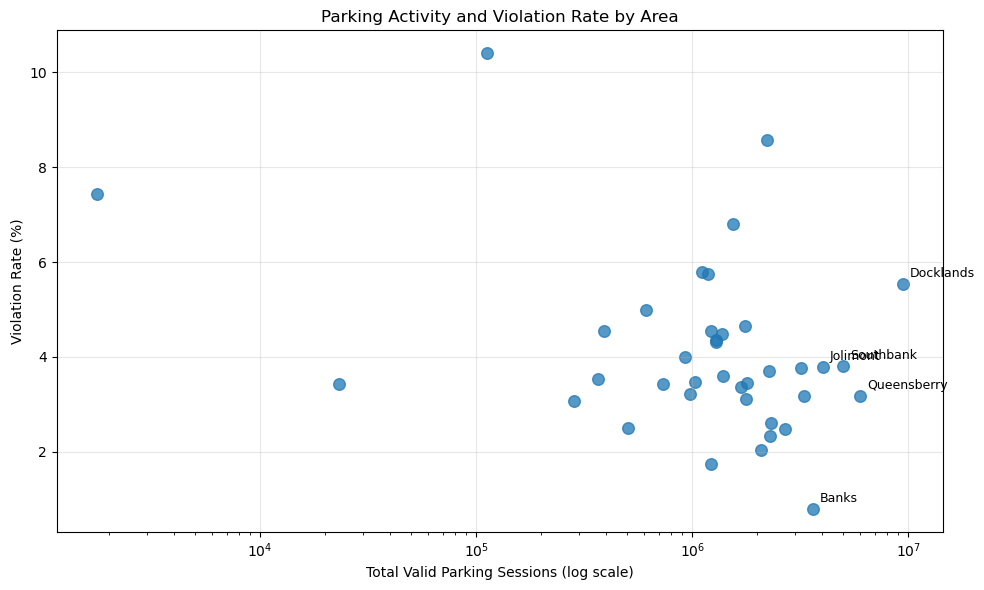

In [88]:
import numpy as np
import matplotlib.pyplot as plt

area_visualisation_pd = (
    area_visualisation_df.toPandas()
)

area_visualisation_pd["AreaLabel"] = (
    area_visualisation_pd["AreaName"]
    .fillna(
        "Area "
        + area_visualisation_pd["AreaId"].astype(str)
    )
)

x = area_visualisation_pd["TotalValidSessions"]
y = area_visualisation_pd["ViolationRate"]

area_activity_violation_correlation = (
    np.corrcoef(
        np.log10(x),
        y
    )[0, 1]
)

print(
    "Correlation between log10(TotalValidSessions) "
    f"and ViolationRate: "
    f"{area_activity_violation_correlation:.3f}"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    x,
    y,
    s=70,
    alpha=0.75
)

# Label the five areas with the most sessions
for _, row in (
    area_visualisation_pd
    .nlargest(5, "TotalValidSessions")
    .iterrows()
):
    ax.annotate(
        row["AreaLabel"],
        (
            row["TotalValidSessions"],
            row["ViolationRate"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xscale("log")
ax.set_xlabel(
    "Total Valid Parking Sessions (log scale)"
)
ax.set_ylabel(
    "Violation Rate (%)"
)
ax.set_title(
    "Parking Activity and Violation Rate by Area"
)
ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

#### Plot 1 Discussion

The plot shows a weak-to-moderate negative association between parking
activity and violation rate. The correlation between the logarithm of total
valid sessions and violation rate was -0.358. Therefore, areas with more
parking sessions did not generally have higher violation rates.

For example, Banks recorded more than 3.6 million valid sessions but had an
overall violation rate of only 0.79%. In contrast, Domain recorded
substantially fewer sessions but had a violation rate of 10.40%. This
suggests that parking activity alone does not explain variation in violation
rates across areas.

A limitation is that this is an area-level aggregated relationship and does
not account for differences in parking restrictions, enforcement activity,
location characteristics or time of day. The correlation also does not
demonstrate causation and may be influenced by low-activity areas with
unusually high violation rates.

### Plot 2: Hourly Parking Activity and Traffic Volume

**Question:** Are hours with higher average parking activity also associated
with higher average traffic volume?

A scatter plot was selected because it directly compares two quantitative
measures. Each point represents one hour of the day, and colour indicates the
hour, allowing both the relationship and its time-of-day pattern to be
examined.

In [89]:
hourly_relationship_df = (
    matched_area_time_blocks_df
    .withColumn(
        "HourOfDay",
        F.hour("BlockStart")
    )
    .groupBy(
        "HourOfDay"
    )
    .agg(
        F.round(
            F.avg("ParkingSessions"),
            2
        ).alias(
            "AverageParkingSessions"
        ),

        F.round(
            F.avg("TrafficVolume"),
            2
        ).alias(
            "AverageTrafficVolume"
        ),

        F.count("*").alias(
            "MatchedBlocks"
        )
    )
    .orderBy(
        "HourOfDay"
    )
    .cache()
)

In [90]:
hourly_relationship_df.show(
    5,
    truncate=False
)

hourly_relationship_count = (
    hourly_relationship_df.count()
)

print(
    "Aggregated dataset row count:",
    hourly_relationship_count
)

+---------+----------------------+--------------------+-------------+
|HourOfDay|AverageParkingSessions|AverageTrafficVolume|MatchedBlocks|
+---------+----------------------+--------------------+-------------+
|0        |110.31                |1494.66             |26620        |
|1        |6.77                  |284.04              |22186        |
|2        |6.09                  |251.7               |20847        |
|3        |5.53                  |241.99              |20028        |
|4        |5.11                  |236.75              |20131        |
+---------+----------------------+--------------------+-------------+
only showing top 5 rows
Aggregated dataset row count: 24


Correlation between average parking sessions and average traffic volume: 0.517


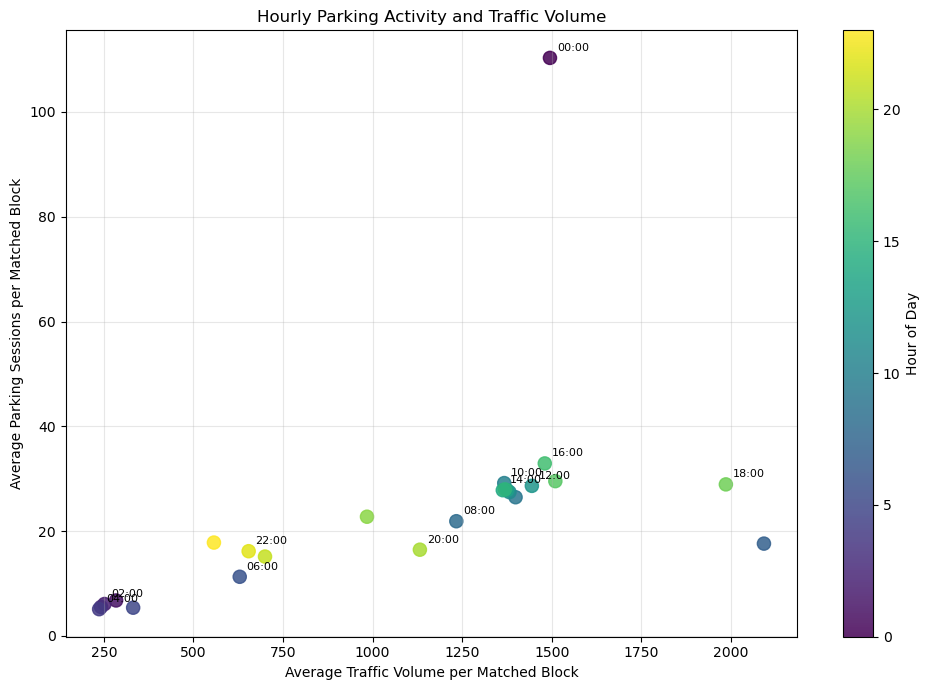

In [91]:
hourly_relationship_pd = (
    hourly_relationship_df
    .toPandas()
    .sort_values("HourOfDay")
)

hourly_parking_traffic_correlation = (
    hourly_relationship_pd[
        "AverageParkingSessions"
    ].corr(
        hourly_relationship_pd[
            "AverageTrafficVolume"
        ]
    )
)

print(
    "Correlation between average parking sessions "
    f"and average traffic volume: "
    f"{hourly_parking_traffic_correlation:.3f}"
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

scatter = ax.scatter(
    hourly_relationship_pd[
        "AverageTrafficVolume"
    ],
    hourly_relationship_pd[
        "AverageParkingSessions"
    ],
    c=hourly_relationship_pd[
        "HourOfDay"
    ],
    cmap="viridis",
    s=90,
    alpha=0.85
)

# Label every second hour to reduce visual crowding
for _, row in hourly_relationship_pd.iterrows():
    if int(row["HourOfDay"]) % 2 == 0:
        ax.annotate(
            f'{int(row["HourOfDay"]):02d}:00',
            (
                row["AverageTrafficVolume"],
                row["AverageParkingSessions"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

colour_bar = plt.colorbar(
    scatter,
    ax=ax
)
colour_bar.set_label(
    "Hour of Day"
)

ax.set_xlabel(
    "Average Traffic Volume per Matched Block"
)
ax.set_ylabel(
    "Average Parking Sessions per Matched Block"
)
ax.set_title(
    "Hourly Parking Activity and Traffic Volume"
)
ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

#### Plot 2 Discussion

The hourly results show a moderate positive relationship between average
parking activity and average traffic volume, with a correlation of 0.517.
Hours with higher traffic volume therefore tended to have higher parking
activity, although the relationship was not consistent across every hour.

The early-morning hours generally had both low traffic volume and low parking
activity, while daytime and evening hours recorded higher values. Midnight
was a clear outlier, with an average of 110.31 parking sessions per matched
block. This is substantially higher than the values recorded during other
hours and may strongly influence the calculated correlation.

A limitation is that the hourly averages combine different areas, weekdays,
weekends and dates. They may therefore hide substantial spatial and daily
variation. The analysis also includes only area-time blocks matched by the
inner join, and the unusual midnight concentration may reflect sensor or
timestamp-recording behaviour rather than an equivalent number of actual
vehicle arrivals.

In [92]:
area_visualisation_df.unpersist()
hourly_relationship_df.unpersist()

DataFrame[HourOfDay: int, AverageParkingSessions: double, AverageTrafficVolume: double, MatchedBlocks: bigint]

Write your dicsussion here.

## Part 3 Query Optimisation (25%) <a class="anchor" name="part-3"></a>
Assume that the following monthly parking report will be generated regularly. A correct query is required first, but it should also execute efficiently on the full dataset. In this section, implement the report, inspect how Spark executes it, and evaluate the optimization.


Monthly parking report  
For each month, identify the five areas with the highest number of peak-hour parking sessions among areas whose peak-hour violation rate is greater than the monthly violation benchmark.  
Area Violation Rate = (Peak-hour sessions where inViolation is true) / (Peak-hour sessions with a valid inViolation value) * 100   
Monthly Violation Benchmark = (Peak-hour sessions where InViolation is true across all areas in the month) / (Peak-hour sessions with a valid InViolation value across all areas in the same month) * 100  
  
Display:  
- month;
- area id;
- area name;
- park session count;
- violation count;
- violation rate;
- monthly rank.  
Report the number of months and total result rows, Display the complete result ordered by Month and Monthly Rank in ascending order.

##### 3.1 DataFrame API and Spark SQL 
Implement the monthly report independently using:  
1. the PySpark DataFrame API;
2. Spark SQL  
Both implementations must begin with the same prepared input data. Do not create the SQL result by registering the completed DataFrame API result as a temporary view.  
  
Complete the following:  
1. Report the row count returned by each implementation
2. Confirm that the results are identical using exceptAll() in both directions, and display both mismatch counts.
3. For each implementation, display the first 20 result rows using the following column order: 
- Month
- AreaId
- AreaName
- PeakSessionCount
- ViolationCount
- ViolationRate
- MonthlyViolationBenchmark
- MonthlyRank
4. Order the displayed results by Month and MonthlyRank in ascending order.
5. Inspect the physical plan for each implementation, and briefly compare the operations. Briefly explain whether Spark selected different execution strategies, and why?


In [93]:
monthly_peak_input_df = (
    parking_enriched_df
    .filter(
        F.col("areaid").isNotNull()
        & F.col("arrivaltime").isNotNull()
        & F.col("isPeak")
    )
    .select(
        F.trunc(
            F.to_date("arrivaltime"),
            "month"
        ).alias("Month"),

        F.col("areaid").alias("AreaId"),

        F.col("AreaName"),

        F.col("inviolation").alias(
            "InViolation"
        )
    )
)

In [94]:
monthly_peak_input_df.show(
    10,
    truncate=False
)

monthly_peak_input_df.printSchema()

+----------+------+---------+-----------+
|Month     |AreaId|AreaName |InViolation|
+----------+------+---------+-----------+
|2018-11-01|35    |Docklands|false      |
|2018-01-01|35    |Docklands|false      |
|2018-05-01|35    |Docklands|false      |
|2018-06-01|35    |Docklands|false      |
|2018-02-01|35    |Docklands|false      |
|2018-01-01|35    |Docklands|false      |
|2018-05-01|35    |Docklands|false      |
|2018-05-01|35    |Docklands|false      |
|2018-10-01|35    |Docklands|false      |
|2018-08-01|35    |Docklands|false      |
+----------+------+---------+-----------+
only showing top 10 rows
root
 |-- Month: date (nullable = true)
 |-- AreaId: integer (nullable = true)
 |-- AreaName: string (nullable = true)
 |-- InViolation: boolean (nullable = true)



In [95]:
monthly_peak_input_df.createOrReplaceTempView(
    "monthly_peak_input"
)

In [96]:
area_month_metrics_df = (
    monthly_peak_input_df
    .groupBy(
        "Month",
        "AreaId",
        "AreaName"
    )
    .agg(
        F.count("*").alias(
            "PeakSessionCount"
        ),

        F.sum(
            F.when(
                F.col("InViolation") == True,
                1
            ).otherwise(0)
        ).alias(
            "ViolationCount"
        ),

        F.count(
            "InViolation"
        ).alias(
            "ValidViolationSessions"
        )
    )
    .withColumn(
        "AreaViolationRateRaw",
        F.when(
            F.col("ValidViolationSessions") > 0,
            (
                F.col("ViolationCount")
                / F.col("ValidViolationSessions")
                * 100
            )
        )
    )
)

In [97]:
monthly_benchmark_df = (
    monthly_peak_input_df
    .groupBy(
        "Month"
    )
    .agg(
        F.sum(
            F.when(
                F.col("InViolation") == True,
                1
            ).otherwise(0)
        ).alias(
            "MonthlyViolationCount"
        ),

        F.count(
            "InViolation"
        ).alias(
            "MonthlyValidViolationSessions"
        )
    )
    .withColumn(
        "MonthlyViolationBenchmarkRaw",
        F.when(
            F.col("MonthlyValidViolationSessions") > 0,
            (
                F.col("MonthlyViolationCount")
                / F.col("MonthlyValidViolationSessions")
                * 100
            )
        )
    )
)

In [98]:
eligible_area_month_df = (
    area_month_metrics_df
    .join(
        monthly_benchmark_df,
        on="Month",
        how="inner"
    )
    .filter(
        F.col("AreaViolationRateRaw")
        > F.col("MonthlyViolationBenchmarkRaw")
    )
)

In [99]:
from pyspark.sql.window import Window

monthly_ranking_window = (
    Window
    .partitionBy("Month")
    .orderBy(
        F.desc("PeakSessionCount"),
        F.asc("AreaId")
    )
)

In [100]:
dataframe_monthly_report_df = (
    eligible_area_month_df
    .withColumn(
        "MonthlyRank",
        F.row_number().over(
            monthly_ranking_window
        )
    )
    .filter(
        F.col("MonthlyRank") <= 5
    )
    .select(
        "Month",
        "AreaId",
        "AreaName",
        "PeakSessionCount",
        "ViolationCount",

        F.round(
            "AreaViolationRateRaw",
            2
        ).alias(
            "ViolationRate"
        ),

        F.round(
            "MonthlyViolationBenchmarkRaw",
            2
        ).alias(
            "MonthlyViolationBenchmark"
        ),

        "MonthlyRank"
    )
    .orderBy(
        F.asc("Month"),
        F.asc("MonthlyRank")
    )
)

In [101]:
dataframe_monthly_report_df.explain(
    mode="formatted"
)

== Physical Plan ==
AdaptiveSparkPlan (64)
+- Sort (63)
   +- Exchange (62)
      +- Project (61)
         +- Filter (60)
            +- Window (59)
               +- WindowGroupLimit (58)
                  +- Sort (57)
                     +- Project (56)
                        +- SortMergeJoin Inner (55)
                           :- Sort (27)
                           :  +- Exchange (26)
                           :     +- Project (25)
                           :        +- Filter (24)
                           :           +- HashAggregate (23)
                           :              +- Exchange (22)
                           :                 +- HashAggregate (21)
                           :                    +- Project (20)
                           :                       +- BroadcastHashJoin LeftOuter BuildRight (19)
                           :                          :- Project (11)
                           :                          :  +- BroadcastHashJoin LeftOut

In [102]:
from pyspark import StorageLevel

dataframe_monthly_report_df = (
    dataframe_monthly_report_df
    .persist(StorageLevel.MEMORY_AND_DISK)
)

dataframe_result_count = (
    dataframe_monthly_report_df.count()
)

dataframe_month_count = (
    dataframe_monthly_report_df
    .select("Month")
    .distinct()
    .count()
)

print(
    "DataFrame API result row count:",
    dataframe_result_count
)

print(
    "Number of months:",
    dataframe_month_count
)

dataframe_monthly_report_df.show(
    20,
    truncate=False
)

DataFrame API result row count: 120
Number of months: 24
+----------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|Month     |AreaId|AreaName       |PeakSessionCount|ViolationCount|ViolationRate|MonthlyViolationBenchmark|MonthlyRank|
+----------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|2018-01-01|35    |Docklands      |85792           |5606          |6.53         |5.34                     |1          |
|2018-01-01|38    |Southbank      |45155           |2470          |5.47         |5.34                     |2          |
|2018-01-01|6     |Titles         |19818           |1115          |5.63         |5.34                     |3          |
|2018-01-01|13    |Princes Theatre|17223           |1252          |7.27         |5.34                     |4          |
|2018-01-01|20    |Courtney       |12275           |1605          |13.08        |5.34                  

In [103]:
sql_monthly_report_df = spark.sql("""
WITH area_month_metrics AS (
    SELECT
        Month,
        AreaId,
        AreaName,
        COUNT(*) AS PeakSessionCount,
        SUM(
            CASE
                WHEN InViolation = TRUE THEN 1
                ELSE 0
            END
        ) AS ViolationCount,
        COUNT(InViolation) AS ValidViolationSessions
    FROM monthly_peak_input
    GROUP BY
        Month,
        AreaId,
        AreaName
),

monthly_benchmark AS (
    SELECT
        Month,
        SUM(
            CASE
                WHEN InViolation = TRUE THEN 1
                ELSE 0
            END
        ) AS MonthlyViolationCount,
        COUNT(InViolation) AS MonthlyValidViolationSessions
    FROM monthly_peak_input
    GROUP BY Month
),

area_with_benchmark AS (
    SELECT
        a.Month,
        a.AreaId,
        a.AreaName,
        a.PeakSessionCount,
        a.ViolationCount,

        (
            CAST(a.ViolationCount AS DOUBLE)
            / CAST(a.ValidViolationSessions AS DOUBLE)
            * 100.0
        ) AS AreaViolationRateRaw,

        (
            CAST(m.MonthlyViolationCount AS DOUBLE)
            / CAST(m.MonthlyValidViolationSessions AS DOUBLE)
            * 100.0
        ) AS MonthlyViolationBenchmarkRaw

    FROM area_month_metrics AS a
    INNER JOIN monthly_benchmark AS m
        ON a.Month = m.Month

    WHERE
        a.ValidViolationSessions > 0
        AND m.MonthlyValidViolationSessions > 0
),

eligible_areas AS (
    SELECT *
    FROM area_with_benchmark
    WHERE
        AreaViolationRateRaw
        > MonthlyViolationBenchmarkRaw
),

ranked_areas AS (
    SELECT
        Month,
        AreaId,
        AreaName,
        PeakSessionCount,
        ViolationCount,
        AreaViolationRateRaw,
        MonthlyViolationBenchmarkRaw,

        ROW_NUMBER() OVER (
            PARTITION BY Month
            ORDER BY
                PeakSessionCount DESC,
                AreaId ASC
        ) AS MonthlyRank

    FROM eligible_areas
)

SELECT
    Month,
    AreaId,
    AreaName,
    PeakSessionCount,
    ViolationCount,
    ROUND(
        AreaViolationRateRaw,
        2
    ) AS ViolationRate,
    ROUND(
        MonthlyViolationBenchmarkRaw,
        2
    ) AS MonthlyViolationBenchmark,
    MonthlyRank

FROM ranked_areas
WHERE MonthlyRank <= 5
ORDER BY
    Month ASC,
    MonthlyRank ASC
""")

In [104]:
sql_monthly_report_df.explain(
    mode="formatted"
)

== Physical Plan ==
AdaptiveSparkPlan (62)
+- Sort (61)
   +- Exchange (60)
      +- Project (59)
         +- Filter (58)
            +- Window (57)
               +- WindowGroupLimit (56)
                  +- Sort (55)
                     +- Project (54)
                        +- SortMergeJoin Inner (53)
                           :- Sort (26)
                           :  +- Exchange (25)
                           :     +- Filter (24)
                           :        +- HashAggregate (23)
                           :           +- Exchange (22)
                           :              +- HashAggregate (21)
                           :                 +- Project (20)
                           :                    +- BroadcastHashJoin LeftOuter BuildRight (19)
                           :                       :- Project (11)
                           :                       :  +- BroadcastHashJoin LeftOuter BuildRight (10)
                           :                       :  

In [105]:
sql_monthly_report_df = (
    sql_monthly_report_df
    .persist(StorageLevel.MEMORY_AND_DISK)
)

sql_result_count = (
    sql_monthly_report_df.count()
)

print(
    "Spark SQL result row count:",
    sql_result_count
)

sql_monthly_report_df.show(
    20,
    truncate=False
)

Spark SQL result row count: 120
+----------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|Month     |AreaId|AreaName       |PeakSessionCount|ViolationCount|ViolationRate|MonthlyViolationBenchmark|MonthlyRank|
+----------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|2018-01-01|35    |Docklands      |85792           |5606          |6.53         |5.34                     |1          |
|2018-01-01|38    |Southbank      |45155           |2470          |5.47         |5.34                     |2          |
|2018-01-01|6     |Titles         |19818           |1115          |5.63         |5.34                     |3          |
|2018-01-01|13    |Princes Theatre|17223           |1252          |7.27         |5.34                     |4          |
|2018-01-01|20    |Courtney       |12275           |1605          |13.08        |5.34                     |5          |
|2018-02

In [106]:
print("DataFrame API schema:")
dataframe_monthly_report_df.printSchema()

print("Spark SQL schema:")
sql_monthly_report_df.printSchema()

DataFrame API schema:
root
 |-- Month: date (nullable = true)
 |-- AreaId: integer (nullable = true)
 |-- AreaName: string (nullable = true)
 |-- PeakSessionCount: long (nullable = false)
 |-- ViolationCount: long (nullable = true)
 |-- ViolationRate: double (nullable = true)
 |-- MonthlyViolationBenchmark: double (nullable = true)
 |-- MonthlyRank: integer (nullable = false)

Spark SQL schema:
root
 |-- Month: date (nullable = true)
 |-- AreaId: integer (nullable = true)
 |-- AreaName: string (nullable = true)
 |-- PeakSessionCount: long (nullable = false)
 |-- ViolationCount: long (nullable = true)
 |-- ViolationRate: double (nullable = true)
 |-- MonthlyViolationBenchmark: double (nullable = true)
 |-- MonthlyRank: integer (nullable = false)



In [107]:
dataframe_minus_sql_count = (
    dataframe_monthly_report_df
    .exceptAll(
        sql_monthly_report_df
    )
    .count()
)

sql_minus_dataframe_count = (
    sql_monthly_report_df
    .exceptAll(
        dataframe_monthly_report_df
    )
    .count()
)

print(
    "DataFrame API EXCEPT ALL Spark SQL:",
    dataframe_minus_sql_count
)

print(
    "Spark SQL EXCEPT ALL DataFrame API:",
    sql_minus_dataframe_count
)

DataFrame API EXCEPT ALL Spark SQL: 0
Spark SQL EXCEPT ALL DataFrame API: 0


### 3.1 DataFrame API and Spark SQL Comparison

Both implementations returned 120 rows covering 24 months, with five ranked
areas for every month. Their schemas were identical. The bidirectional
exceptAll comparison returned zero mismatches in both directions, confirming
that the DataFrame API and Spark SQL implementations produced exactly the
same result, including duplicate multiplicities.

The two formatted physical plans were structurally very similar. Both used
AdaptiveSparkPlan, scanned the parking-data lineage separately for the
area-month metrics and monthly benchmark, and used partial and final
HashAggregate operations. Both plans introduced Exchanges for the grouped
aggregations and used an inner SortMergeJoin on Month with the violation-rate
comparison included in the join condition.

After the join, both implementations sorted eligible areas by month, peak
session count and AreaId. Spark then used WindowGroupLimit and a row_number
window to retain the top five areas per month, followed by a final range
Exchange and sort for the requested output ordering.

The SQL plan contained 62 numbered nodes compared with 64 in the DataFrame
plan because Catalyst combined or repositioned some Project and Filter
operations. This did not represent a materially different execution
strategy. Both APIs were converted into comparable logical plans and
optimised by the same Catalyst optimiser.

##### 3.2 Baseline plan and Spark UI analysis  
Select either SQL or DataFrame API from Section 3.1 as a baseline. Clearly state which implementation you selected.  
Before running the baseline query, set: sc.setJobDescription(f"A1-P3-2-Baseline-{student_auth_code}")  
Execute an action that materialises the complete final result and record the wall-clock execution time. Use the same action later when evaluating the optimised query.  
Submit and include:  
- the formatted physical plan, you may refer to the plan already printed in Section 3.1 rather than printing it again.
- Spark UI screenshots clearly showing: the job description, the SQL/DAG, the relevant stage details, relevant shuffle-read, shuffle-write figures, where applicable.
- the measured execution time;  
In no more than 300 words:  
1. Identify the most expensive stages or operations.
2. Support the explanation using numbers visible in your screenshots.
3. Suggest an improvement strategy.


Write your discussion here.

### 3.2 Baseline Selection

The DataFrame API implementation was selected as the baseline. It produced
the verified 120-row monthly report and provides a clear sequence of
aggregations, join operations and window-based ranking for subsequent
performance analysis.

In [108]:
dataframe_monthly_report_df.unpersist(
    blocking=True
)

sql_monthly_report_df.unpersist(
    blocking=True
)

spark.catalog.clearCache()

In [109]:
import time

sc.setJobDescription(
    f"A1-P3-2-Baseline-{student_auth_code}"
)

baseline_start_time = time.perf_counter()

baseline_result_rows = (
    dataframe_monthly_report_df.collect()
)

baseline_execution_seconds = (
    time.perf_counter()
    - baseline_start_time
)

sc.setJobDescription(None)

print(
    "Baseline result row count:",
    len(baseline_result_rows)
)

print(
    "Baseline execution time:",
    f"{baseline_execution_seconds:.2f} seconds"
)

Baseline result row count: 120
Baseline execution time: 364.29 seconds


### 3.2 Baseline Plan and Performance Analysis

The DataFrame API baseline returned 120 rows and required 364.29 seconds.
The physical plan and SQL DAG showed two independent branches originating
from the parking-data lineage. One branch calculated the area-month metrics,
while the other independently calculated the monthly violation benchmark.

Stages 330 and 331 were the dominant stages. Each scanned the complete
8.6 GiB parking dataset containing 72,912,582 records using 69 tasks. Stage
330 took 3.1 minutes and wrote 965.2 KiB of shuffle data, while Stage 331
remained active for 6.1 minutes and wrote only 58.3 KiB. The task input sizes
were generally 128.1 MiB, and median task durations were approximately
10–11 seconds, with maxima of 13 seconds. This indicates that severe
partition skew was not the main performance problem.

The later shuffle volumes were small compared with the 17.2 GiB read across
the two scan branches. Therefore, the primary cost was scanning, parsing and
processing the large parking source twice, together with repeating its
lookup-join lineage.

A suitable improvement is to calculate the area-month aggregates once and
derive the monthly benchmark by summing those aggregated violation counts
with a month-partitioned window. This should remove the second full parking
scan and the SortMergeJoin between the area and benchmark branches while
preserving the report result.

In [110]:
optimized_area_month_metrics_df = (
    monthly_peak_input_df
    .groupBy(
        "Month",
        "AreaId",
        "AreaName"
    )
    .agg(
        F.count("*").alias(
            "PeakSessionCount"
        ),

        F.sum(
            F.when(
                F.col("InViolation") == True,
                1
            ).otherwise(0)
        ).alias(
            "ViolationCount"
        ),

        F.count(
            "InViolation"
        ).alias(
            "ValidViolationSessions"
        )
    )
)

In [111]:
monthly_totals_window = (
    Window
    .partitionBy("Month")
)

optimized_metrics_with_benchmark_df = (
    optimized_area_month_metrics_df
    .withColumn(
        "MonthlyViolationCount",
        F.sum("ViolationCount").over(
            monthly_totals_window
        )
    )
    .withColumn(
        "MonthlyValidViolationSessions",
        F.sum("ValidViolationSessions").over(
            monthly_totals_window
        )
    )
    .withColumn(
        "AreaViolationRateRaw",
        F.when(
            F.col("ValidViolationSessions") > 0,
            (
                F.col("ViolationCount")
                / F.col("ValidViolationSessions")
                * 100
            )
        )
    )
    .withColumn(
        "MonthlyViolationBenchmarkRaw",
        F.when(
            F.col("MonthlyValidViolationSessions") > 0,
            (
                F.col("MonthlyViolationCount")
                / F.col("MonthlyValidViolationSessions")
                * 100
            )
        )
    )
    .filter(
        F.col("AreaViolationRateRaw")
        > F.col("MonthlyViolationBenchmarkRaw")
    )
)

In [112]:
optimized_ranking_window = (
    Window
    .partitionBy("Month")
    .orderBy(
        F.desc("PeakSessionCount"),
        F.asc("AreaId")
    )
)

optimized_monthly_report_df = (
    optimized_metrics_with_benchmark_df
    .withColumn(
        "MonthlyRank",
        F.row_number().over(
            optimized_ranking_window
        )
    )
    .filter(
        F.col("MonthlyRank") <= 5
    )
    .select(
        "Month",
        "AreaId",
        "AreaName",
        "PeakSessionCount",
        "ViolationCount",

        F.round(
            "AreaViolationRateRaw",
            2
        ).alias(
            "ViolationRate"
        ),

        F.round(
            "MonthlyViolationBenchmarkRaw",
            2
        ).alias(
            "MonthlyViolationBenchmark"
        ),

        "MonthlyRank"
    )
    .orderBy(
        F.asc("Month"),
        F.asc("MonthlyRank")
    )
)

In [113]:
optimized_monthly_report_df.explain(
    mode="formatted"
)

== Physical Plan ==
AdaptiveSparkPlan (36)
+- Sort (35)
   +- Exchange (34)
      +- Project (33)
         +- Filter (32)
            +- Window (31)
               +- WindowGroupLimit (30)
                  +- Sort (29)
                     +- Project (28)
                        +- Filter (27)
                           +- Window (26)
                              +- Sort (25)
                                 +- Exchange (24)
                                    +- HashAggregate (23)
                                       +- Exchange (22)
                                          +- HashAggregate (21)
                                             +- Project (20)
                                                +- BroadcastHashJoin LeftOuter BuildRight (19)
                                                   :- Project (11)
                                                   :  +- BroadcastHashJoin LeftOuter BuildRight (10)
                                                   :     :- Project

##### 3.3 Evaluate one optimisation  
Implement one optimisation based on the evidence and reasoning presented in Section 3.2. Briefly state what you changed and why you expect it to improve execution.  
Before executing it, set: sc.setJobDescription(f"A1-P3-3-Optimised-{student_auth_code}")  
Then:  
1. Run the baseline and revised queries under the same conditions;
2. Confirm that the optimised query produces exactly the same result as the baseline
3. Record the execution time and collect the corresponding Spark UI evidence.
4. Decide whether the optimisation should be retained, justify your decision.
5. A technically reasonable improvement and evidence-based evaluation are required for full marks.


In [114]:
import time
from collections import Counter

# Ensure that neither final result is retained in Spark's cache.
dataframe_monthly_report_df.unpersist(blocking=True)
sql_monthly_report_df.unpersist(blocking=True)
optimized_monthly_report_df.unpersist(blocking=True)
spark.catalog.clearCache()


def timed_collect(dataframe, job_description):
    """
    Fully materialise a DataFrame using collect() and return
    both its rows and execution time.
    """
    spark.catalog.clearCache()
    sc.setJobDescription(job_description)

    try:
        start_time = time.perf_counter()
        rows = dataframe.collect()
        execution_seconds = time.perf_counter() - start_time
    finally:
        sc.setJobDescription(None)

    return rows, execution_seconds


# Rerun the baseline under the comparison conditions.
baseline_rows, baseline_comparison_seconds = timed_collect(
    dataframe_monthly_report_df,
    f"A1-P3-2-Baseline-{student_auth_code}"
)

print("Baseline row count:", len(baseline_rows))
print(
    "Baseline execution time:",
    round(baseline_comparison_seconds, 2),
    "seconds"
)


# Run the optimised implementation using the same action.
optimized_rows, optimized_execution_seconds = timed_collect(
    optimized_monthly_report_df,
    f"A1-P3-3-Optimised-{student_auth_code}"
)

print("Optimised row count:", len(optimized_rows))
print(
    "Optimised execution time:",
    round(optimized_execution_seconds, 2),
    "seconds"
)

Baseline row count: 120
Baseline execution time: 0.17 seconds
Optimised row count: 120
Optimised execution time: 200.48 seconds


In [115]:
# Compare schemas.
schemas_identical = (
    dataframe_monthly_report_df.schema
    == optimized_monthly_report_df.schema
)

# Counter preserves duplicate multiplicities.
baseline_counter = Counter(
    tuple(row) for row in baseline_rows
)

optimized_counter = Counter(
    tuple(row) for row in optimized_rows
)

rows_identical = baseline_counter == optimized_counter

print("Schemas identical:", schemas_identical)
print("Rows exactly identical:", rows_identical)

Schemas identical: True
Rows exactly identical: True


In [116]:
baseline_materialised_df = spark.createDataFrame(
    baseline_rows,
    schema=dataframe_monthly_report_df.schema
)

optimized_materialised_df = spark.createDataFrame(
    optimized_rows,
    schema=optimized_monthly_report_df.schema
)

baseline_minus_optimized = (
    baseline_materialised_df
    .exceptAll(optimized_materialised_df)
    .count()
)

optimized_minus_baseline = (
    optimized_materialised_df
    .exceptAll(baseline_materialised_df)
    .count()
)

print(
    "Baseline EXCEPT ALL Optimised:",
    baseline_minus_optimized
)

print(
    "Optimised EXCEPT ALL Baseline:",
    optimized_minus_baseline
)

Baseline EXCEPT ALL Optimised: 0
Optimised EXCEPT ALL Baseline: 0


In [117]:
time_saved_seconds = (
    baseline_comparison_seconds
    - optimized_execution_seconds
)

runtime_reduction_percentage = (
    time_saved_seconds
    / baseline_comparison_seconds
    * 100
)

speedup = (
    baseline_comparison_seconds
    / optimized_execution_seconds
)

print(
    "Time saved:",
    round(time_saved_seconds, 2),
    "seconds"
)

print(
    "Runtime reduction:",
    round(runtime_reduction_percentage, 2),
    "%"
)

print(
    "Speed-up:",
    round(speedup, 2),
    "times"
)

Time saved: -200.31 seconds
Runtime reduction: -114709.16 %
Speed-up: 0.0 times
